# 🌿 MODIS Vegetation Baseline & Anomaly Analysis

**Purpose:** Build a 20-year climatological baseline (2000–2020), compute anomalies for analysis years, quantify drought conditions, and classify drought types.

---

## Workflow Overview
```
1. Setup & AOI loading
2. Build 20-year baseline (2000–2020)
   ├── Monthly climatology (mean ± std per calendar month)
   └── Percentile envelopes (10th, 25th, 75th, 90th)
3. Fetch analysis-period data (2021–present)
4. Compute anomalies
   ├── Absolute anomaly  (observed − baseline_mean)
   └── Standardised anomaly / Z-score
5. VCI calculation against the 20-year baseline
6. Drought flagging & classification
7. Visualisation
   ├── Long-term baseline ribbon plots
   ├── Anomaly time-series
   ├── Drought heatmaps
   └── Condition summary charts
```
---

## 1 · Setup

In [2]:
# ── Core imports ─────────────────────────────────────────────────────────────
import ee
import geemap
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
from matplotlib.ticker import MultipleLocator
import matplotlib.ticker as mticker
from scipy import stats as scipy_stats
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings, os, json, zipfile, time
from pathlib import Path
from datetime import datetime

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
})

MONTH_ABBR = ['Jan','Feb','Mar','Apr','May','Jun',
              'Jul','Aug','Sep','Oct','Nov','Dec']

print("✅ Imports successful")

✅ Imports successful


In [7]:
# ── Configuration ─────────────────────────────────────────────────────────────
CONFIG = {
    # Earth Engine
    "ee_project"      : "ee-my-ndungu",          # ← change to your project
    "modis_collection": "MODIS/061/MOD13Q1",
    "scale"           : 250,                      # metres; increase to 500/1000 for speed

    # Baseline period
    "baseline_start"  : 2000,
    "baseline_end"    : 2020,

    # Analysis years (post-baseline)
    "analysis_years"  : list(range(2021, 2025)),  # extend as needed

    # Outputs
    "output_dir"      : "baseline_outputs",
}

# Drought thresholds (Z-score based)
DROUGHT_THRESHOLDS = {
    "extreme"  : -2.0,   # Z ≤ -2.0
    "severe"   : -1.5,   # -2.0 < Z ≤ -1.5
    "moderate" : -1.0,   # -1.5 < Z ≤ -1.0
    "mild"     : -0.5,   # -1.0 < Z ≤ -0.5
    "normal"   :  0.5,   # |Z| < 0.5
}

# Drought thresholds (VCI based)  
VCI_THRESHOLDS = {
    "extreme"  : 10,
    "severe"   : 20,
    "moderate" : 35,
    "mild"     : 50,
    "normal"   : 65,
}

# Colour scheme (shared across all plots)
DROUGHT_COLORS = {
    "extreme"      : "#8B0000",
    "severe"       : "#D73027",
    "moderate"     : "#FC8D59",
    "mild"         : "#FEE090",
    "normal"       : "#91BFDB",
    "above_normal" : "#2166AC",
}

# Create output directories
for sub in ['baseline','anomalies','drought','trends','composites']:
    Path(CONFIG['output_dir'], sub).mkdir(parents=True, exist_ok=True)

print(f"✅ Config ready baseline {CONFIG['baseline_start']}–{CONFIG['baseline_end']}  "
      f" analysis years{CONFIG['analysis_years']}")

✅ Config ready baseline 2000–2020   analysis years[2021, 2022, 2023, 2024]


In [8]:
# ── Earth Engine initialisation ───────────────────────────────────────────────
try:
    ee.Initialize(project=CONFIG['ee_project'])
    print(f"✅ Earth Engine initialised  →  project: {CONFIG['ee_project']}")
except Exception:
    print("🔐 Authenticating…")
    ee.Authenticate()
    ee.Initialize(project=CONFIG['ee_project'])
    print("✅ Authenticated & initialised")

✅ Earth Engine initialised  →  project: ee-my-ndungu


## 2 · Load AOI

In [9]:
# ── AOI upload widget ──────────────────────────────────────────────────────────
upload_widget = widgets.FileUpload(
    accept='.zip,.geojson,.json,.shp',
    multiple=False,
    description='📁 Upload AOI',
    style={'description_width': 'initial'}
)
display(upload_widget)
print("⏳ Upload your AOI file above, then run the next cell.")

FileUpload(value=(), accept='.zip,.geojson,.json,.shp', description='📁 Upload AOI')

⏳ Upload your AOI file above, then run the next cell.


In [10]:
# ── Save & load AOI ────────────────────────────────────────────────────────────
def save_upload(widget):
    """Handles both old (dict) and new (tuple) ipywidgets formats."""
    if isinstance(widget.value, dict):
        f = list(widget.value.values())[0]
        name, content = f['metadata']['name'], f['content']
    else:
        f = widget.value[0]
        name, content = f['name'], f['content']
    with open(name, 'wb') as fh:
        fh.write(content)
    return name

def load_aoi(filepath):
    """Load shapefile / GeoJSON / ZIP → GeoDataFrame + EE FeatureCollection."""
    ext = Path(filepath).suffix.lower()
    if ext == '.zip':
        extract_dir = Path('_aoi_tmp')
        extract_dir.mkdir(exist_ok=True)
        with zipfile.ZipFile(filepath) as z:
            z.extractall(extract_dir)
        shps = list(extract_dir.glob('*.shp'))
        if not shps:
            raise FileNotFoundError('No .shp found inside ZIP')
        gdf = gpd.read_file(shps[0])
    else:
        gdf = gpd.read_file(filepath)
    if gdf.crs and gdf.crs.to_epsg() != 4326:
        gdf = gdf.to_crs('EPSG:4326')
    ee_fc = geemap.geopandas_to_ee(gdf)
    return gdf, ee_fc

if not upload_widget.value:
    raise RuntimeError("⚠️  No file uploaded. Upload an AOI file first.")

aoi_path = save_upload(upload_widget)
aoi_gdf, aoi_ee = load_aoi(aoi_path)
aoi_geom = aoi_ee.geometry()

area_km2 = aoi_gdf.to_crs(epsg=3857).geometry.area.sum() / 1e6
bounds   = aoi_gdf.total_bounds

print(f"✅ AOI loaded   |  features: {len(aoi_gdf)}  |  area: {area_km2:,.1f} km²")
print(f"   Bounds: W {bounds[0]:.3f}  S {bounds[1]:.3f}  E {bounds[2]:.3f}  N {bounds[3]:.3f}")

✅ AOI loaded   |  features: 1  |  area: 2,561.0 km²
   Bounds: W 36.491  S -1.312  E 37.363  N -0.757


In [11]:
# ── Quick AOI preview ──────────────────────────────────────────────────────────
m = geemap.Map()
m.centerObject(aoi_ee, zoom=7)
m.addLayer(aoi_ee, {'color': '#E63946'}, 'AOI')
m

Map(center=[-1.0663333046950283, 36.82274849394715], controls=(WidgetControl(options=['position', 'transparent…

## 3 · Helper Functions (scaling, reduction)

In [12]:
# ── EE helper functions ────────────────────────────────────────────────────────

def scale_modis(image):
    """
    Scale MODIS NDVI & EVI from raw integers → float [-0.2, 1.0].
    MODIS stores scaled integers: actual = raw × 0.0001
    Returns a clean 2-band image preserving all properties.
    """
    ndvi = image.select('NDVI').multiply(0.0001).rename('NDVI')
    evi  = image.select('EVI' ).multiply(0.0001).rename('EVI')
    return (image.select([])
                 .addBands([ndvi, evi])
                 .copyProperties(image, image.propertyNames()))


def get_collection(start_year, end_year):
    """
    Fetch, scale, and return MODIS MOD13Q1 for a year range.
    """
    return (ee.ImageCollection(CONFIG['modis_collection'])
              .filterBounds(aoi_geom)
              .filterDate(f"{start_year}-01-01", f"{end_year}-12-31")
              .map(scale_modis))


def reduce_to_scalar(image, reducer=ee.Reducer.mean()):
    """Spatial reduction of an image over the AOI → dict."""
    return image.reduceRegion(
        reducer   = reducer,
        geometry  = aoi_geom,
        scale     = CONFIG['scale'],
        maxPixels = 1e10,
        tileScale = 4,
    ).getInfo()


def monthly_stats_for_year(year, collection):
    """
    Compute monthly mean NDVI & EVI for a single year.
    Returns a list of dicts (one per month that has data).
    """
    rows = []
    for m in range(1, 13):
        start = f"{year}-{m:02d}-01"
        # End = first day of next month (EE filterDate is exclusive at end)
        if m < 12:
            end = f"{year}-{m+1:02d}-01"
        else:
            end = f"{year+1}-01-01"

        col = collection.filterDate(start, end)
        cnt = col.size().getInfo()
        if cnt == 0:
            continue

        img   = col.mean()
        means = reduce_to_scalar(img, ee.Reducer.mean())
        stds  = reduce_to_scalar(img, ee.Reducer.stdDev())

        rows.append({
            'year'       : year,
            'month'      : m,
            'date'       : pd.Timestamp(year, m, 15),
            'ndvi_mean'  : means.get('NDVI'),
            'ndvi_std'   : stds.get('NDVI'),
            'evi_mean'   : means.get('EVI'),
            'evi_std'    : stds.get('EVI'),
            'n_images'   : cnt,
        })
    return rows


print("✅ Helper functions defined")

✅ Helper functions defined


## 4 · Build 20-Year Baseline (2000–2020)

> **Runtime note** — this section makes one EE call per year × 12 months.  
> For a typical national AOI it takes **10–25 minutes**.  
> Results are cached to CSV so you only run this once.

In [13]:
# ── Fetch or load cached baseline ─────────────────────────────────────────────
BASELINE_CACHE = Path(CONFIG['output_dir']) / 'baseline' / 'baseline_monthly_raw.csv'

if BASELINE_CACHE.exists():
    print(f"📦 Loading cached baseline from {BASELINE_CACHE}")
    df_baseline_raw = pd.read_csv(BASELINE_CACHE, parse_dates=['date'])
    print(f"   ✅ Loaded  {len(df_baseline_raw)} rows  "
          f"({df_baseline_raw.year.min()}–{df_baseline_raw.year.max()})")
else:
    print(f"📡 Fetching baseline data  ({CONFIG['baseline_start']}–{CONFIG['baseline_end']})")
    print("   This will take ~15–25 min for a large AOI…")
    
    baseline_coll = get_collection(CONFIG['baseline_start'], CONFIG['baseline_end'])
    all_rows = []

    baseline_years = range(CONFIG['baseline_start'], CONFIG['baseline_end'] + 1)
    for i, yr in enumerate(baseline_years):
        print(f"   [{i+1:2d}/{len(baseline_years)}] year {yr} …", end=' ', flush=True)
        rows = monthly_stats_for_year(yr, baseline_coll)
        all_rows.extend(rows)
        print(f"{len(rows)} months")

    df_baseline_raw = pd.DataFrame(all_rows)
    df_baseline_raw.to_csv(BASELINE_CACHE, index=False)
    print(f"\n✅ Baseline saved → {BASELINE_CACHE}")

df_baseline_raw.head()

📡 Fetching baseline data  (2000–2020)
   This will take ~15–25 min for a large AOI…
   [ 1/21] year 2000 … 11 months
   [ 2/21] year 2001 … 12 months
   [ 3/21] year 2002 … 12 months
   [ 4/21] year 2003 … 12 months
   [ 5/21] year 2004 … 12 months
   [ 6/21] year 2005 … 12 months
   [ 7/21] year 2006 … 12 months
   [ 8/21] year 2007 … 12 months
   [ 9/21] year 2008 … 12 months
   [10/21] year 2009 … 12 months
   [11/21] year 2010 … 12 months
   [12/21] year 2011 … 12 months
   [13/21] year 2012 … 12 months
   [14/21] year 2013 … 12 months
   [15/21] year 2014 … 12 months
   [16/21] year 2015 … 12 months
   [17/21] year 2016 … 12 months
   [18/21] year 2017 … 12 months
   [19/21] year 2018 … 12 months
   [20/21] year 2019 … 12 months
   [21/21] year 2020 … 12 months

✅ Baseline saved → baseline_outputs/baseline/baseline_monthly_raw.csv


,year,month,date,ndvi_mean,ndvi_std,evi_mean,evi_std,n_images
0,2000,2,2000-02-15,0.505457,0.150537,0.280666,0.091493,1
1,2000,3,2000-03-15,0.496578,0.158555,0.272542,0.089873,2
2,2000,4,2000-04-15,0.559033,0.157290,0.306830,0.100782,2
3,2000,5,2000-05-15,0.585838,0.173397,0.345583,0.120208,2
4,2000,6,2000-06-15,0.504610,0.168130,0.286526,0.109475,2


In [14]:
# ── Compute monthly climatology ────────────────────────────────────────────────
# For each calendar month: mean, std, and key percentiles across all baseline years

clim_rows = []
for month in range(1, 13):
    sub = df_baseline_raw[df_baseline_raw.month == month].dropna(subset=['ndvi_mean', 'evi_mean'])
    if len(sub) == 0:
        continue

    clim_rows.append({
        'month'        : month,
        'n_years'      : len(sub),

        # NDVI climatology
        'ndvi_clim_mean' : sub.ndvi_mean.mean(),
        'ndvi_clim_std'  : sub.ndvi_mean.std(),
        'ndvi_clim_p10'  : sub.ndvi_mean.quantile(0.10),
        'ndvi_clim_p25'  : sub.ndvi_mean.quantile(0.25),
        'ndvi_clim_p75'  : sub.ndvi_mean.quantile(0.75),
        'ndvi_clim_p90'  : sub.ndvi_mean.quantile(0.90),
        'ndvi_clim_min'  : sub.ndvi_mean.min(),
        'ndvi_clim_max'  : sub.ndvi_mean.max(),

        # EVI climatology
        'evi_clim_mean'  : sub.evi_mean.mean(),
        'evi_clim_std'   : sub.evi_mean.std(),
        'evi_clim_p10'   : sub.evi_mean.quantile(0.10),
        'evi_clim_p25'   : sub.evi_mean.quantile(0.25),
        'evi_clim_p75'   : sub.evi_mean.quantile(0.75),
        'evi_clim_p90'   : sub.evi_mean.quantile(0.90),
        'evi_clim_min'   : sub.evi_mean.min(),
        'evi_clim_max'   : sub.evi_mean.max(),
    })

df_clim = pd.DataFrame(clim_rows)

clim_path = Path(CONFIG['output_dir']) / 'baseline' / 'climatology.csv'
df_clim.to_csv(clim_path, index=False)

print("📊 Monthly climatology (2000–2020):")
print(df_clim[['month','ndvi_clim_mean','ndvi_clim_std','evi_clim_mean','evi_clim_std']].to_string(index=False))

📊 Monthly climatology (2000–2020):
 month  ndvi_clim_mean  ndvi_clim_std  evi_clim_mean  evi_clim_std
     1        0.647541       0.053122       0.387092      0.045627
     2        0.590923       0.059615       0.350712      0.046940
     3        0.573675       0.056021       0.340317      0.043235
     4        0.596268       0.042336       0.365540      0.038859
     5        0.633583       0.070685       0.397957      0.036188
     6        0.585724       0.067779       0.363596      0.041339
     7        0.529725       0.072675       0.305335      0.037228
     8        0.535811       0.050459       0.298524      0.028127
     9        0.536184       0.042432       0.308410      0.026781
    10        0.524931       0.069829       0.307116      0.045823
    11        0.616782       0.049849       0.375788      0.039102
    12        0.676558       0.033937       0.405699      0.032099


## 5 · Plot the Baseline Climatology

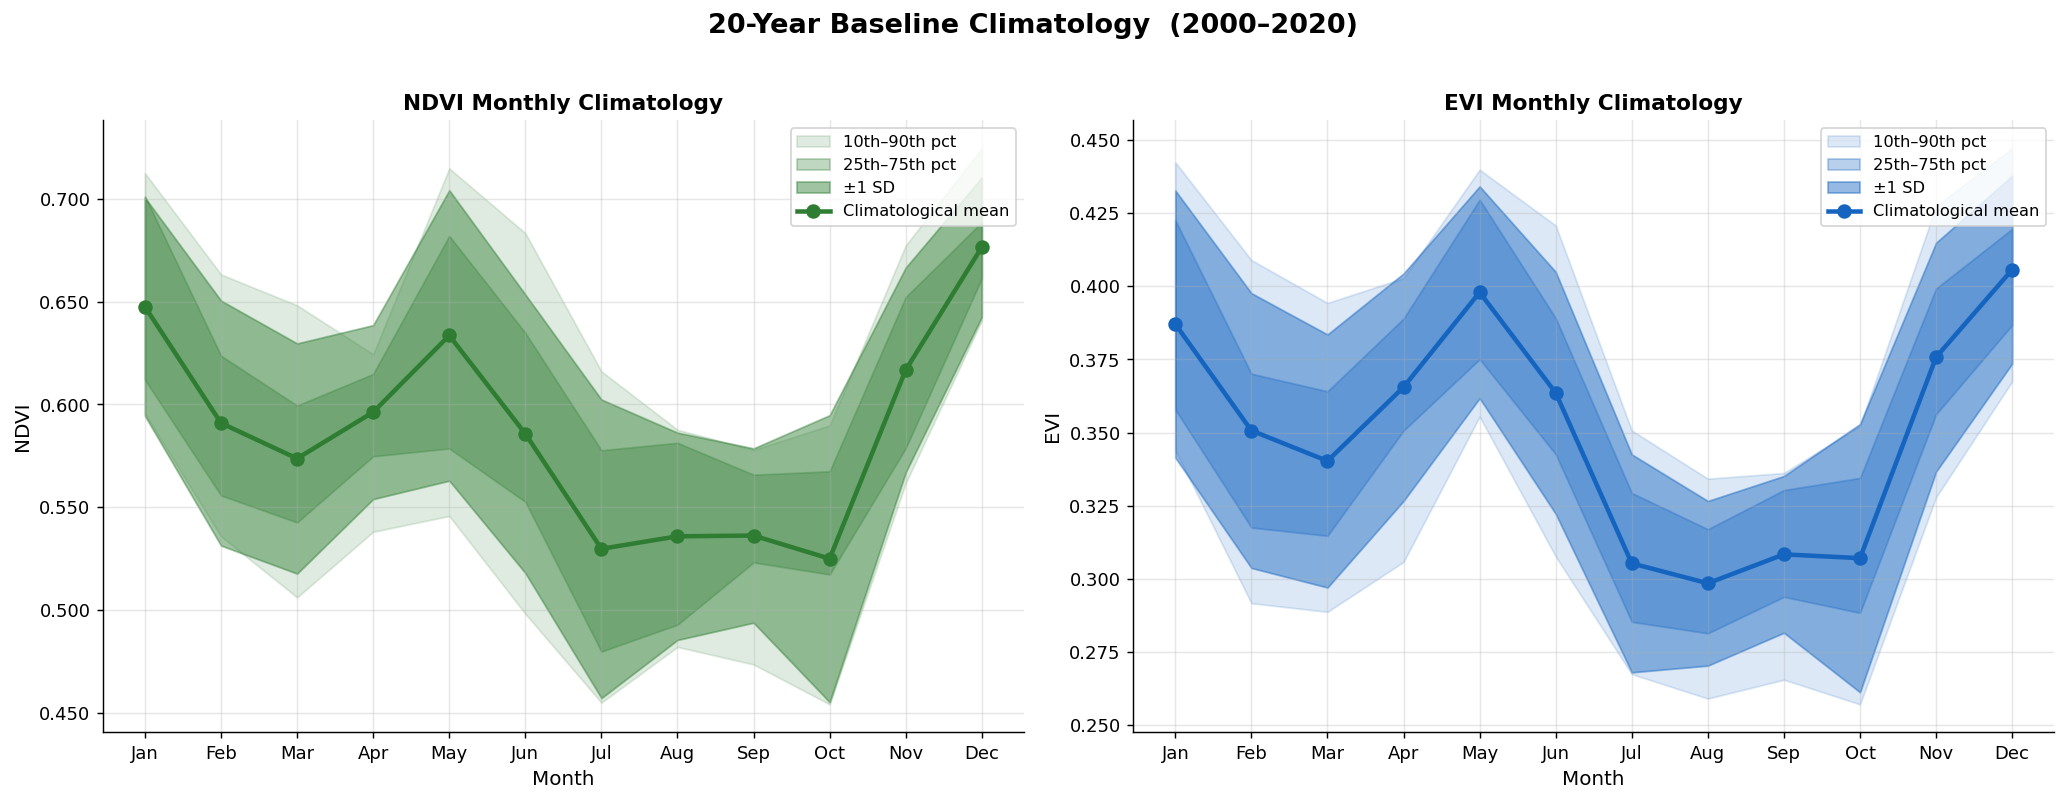

💾 Saved → baseline/climatology_ribbon.png


In [15]:
# ── Baseline climatology ribbon plot ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig.suptitle(f'20-Year Baseline Climatology  ({CONFIG["baseline_start"]}–{CONFIG["baseline_end"]})',
             fontsize=15, fontweight='bold', y=1.02)

for ax, idx, clr in zip(axes, ['ndvi', 'evi'], ['#2e7d32', '#1565c0']):
    mean  = df_clim[f'{idx}_clim_mean'].values
    std   = df_clim[f'{idx}_clim_std'].values
    p10   = df_clim[f'{idx}_clim_p10'].values
    p90   = df_clim[f'{idx}_clim_p90'].values
    p25   = df_clim[f'{idx}_clim_p25'].values
    p75   = df_clim[f'{idx}_clim_p75'].values
    x     = df_clim.month.values

    # Shaded bands
    ax.fill_between(x, p10, p90,  alpha=0.15, color=clr, label='10th–90th pct')
    ax.fill_between(x, p25, p75,  alpha=0.30, color=clr, label='25th–75th pct')
    ax.fill_between(x, mean-std, mean+std, alpha=0.45, color=clr, label='±1 SD')

    # Mean line
    ax.plot(x, mean, 'o-', color=clr, linewidth=2.5, markersize=7, label='Climatological mean')

    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_ABBR, fontsize=10)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel(idx.upper(), fontsize=11)
    ax.set_title(f'{idx.upper()} Monthly Climatology', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

plt.tight_layout()
fig.savefig(Path(CONFIG['output_dir'])/'baseline'/'climatology_ribbon.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → baseline/climatology_ribbon.png")

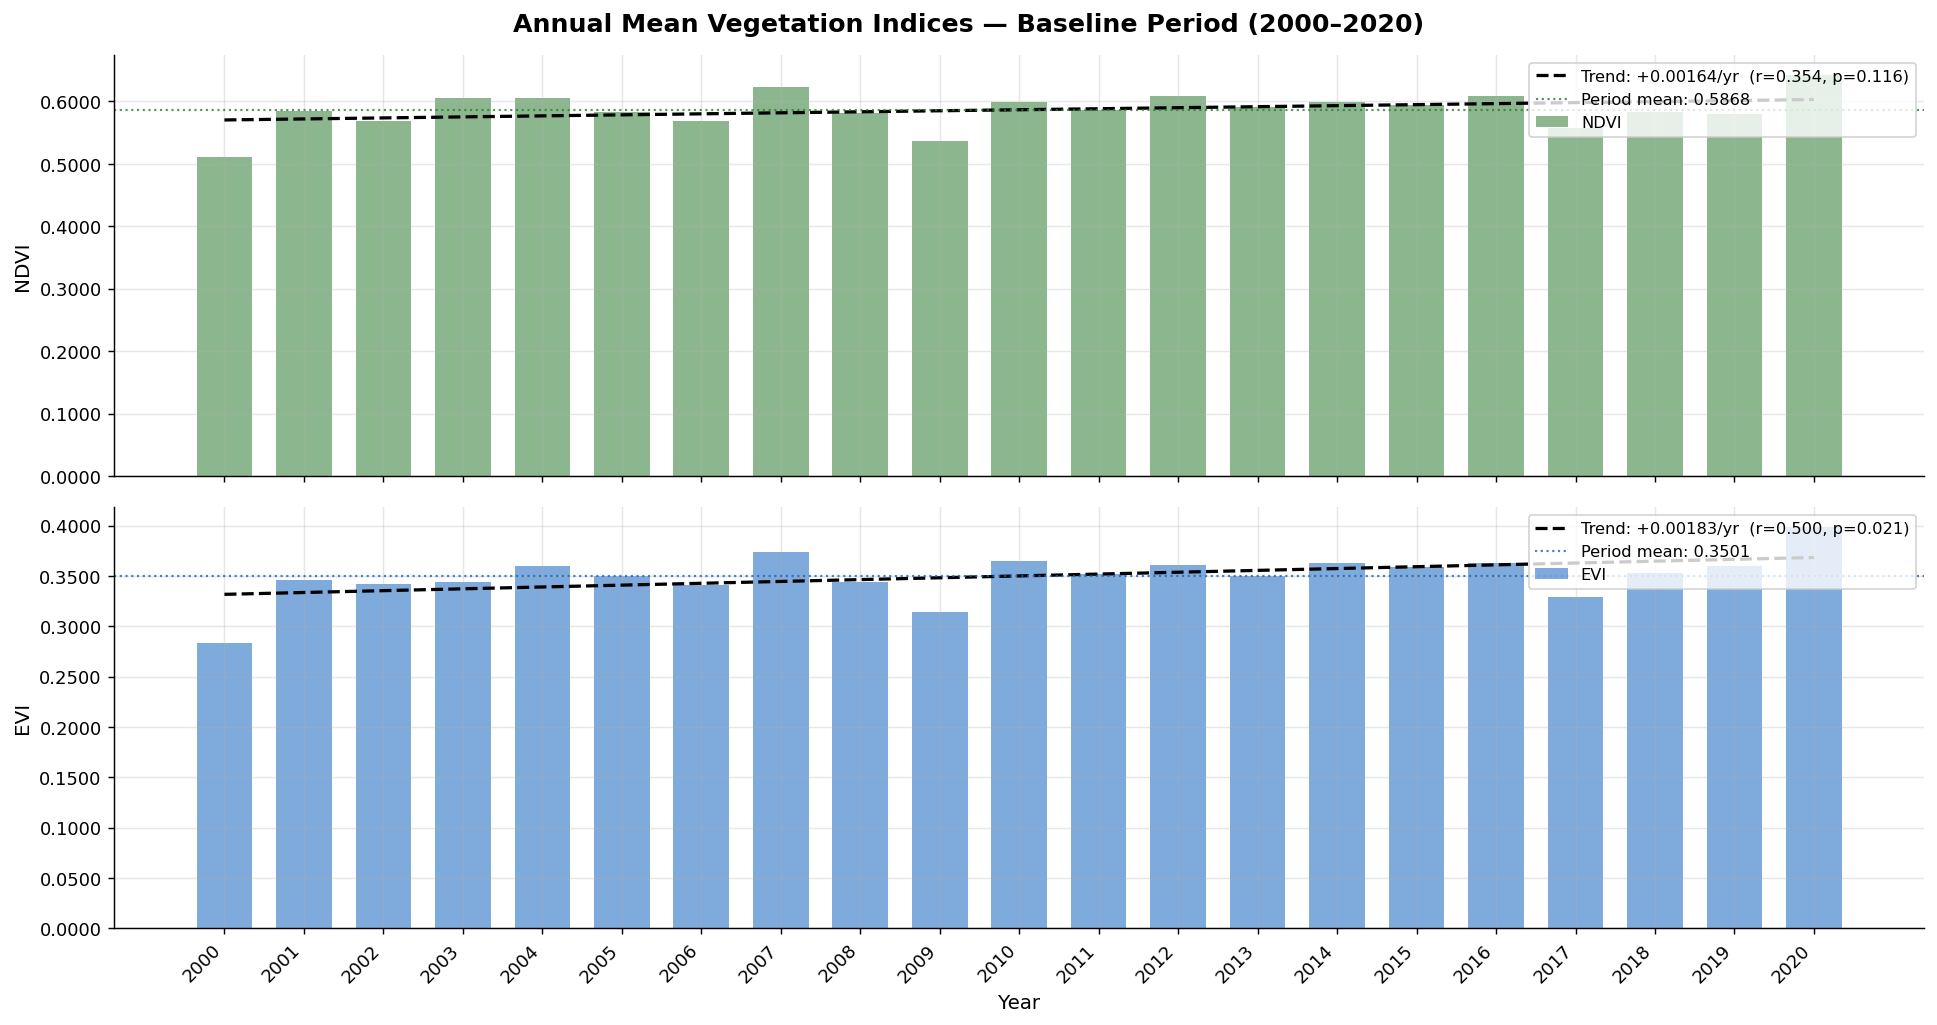

💾 Saved → baseline/annual_trend_baseline.png


In [16]:
# ── Long-term annual mean trend across baseline ────────────────────────────────
annual_baseline = (df_baseline_raw
                   .dropna(subset=['ndvi_mean', 'evi_mean'])
                   .groupby('year')[['ndvi_mean','evi_mean']]
                   .mean()
                   .reset_index())

fig, axes = plt.subplots(2, 1, figsize=(15, 8), sharex=True)
fig.suptitle(f'Annual Mean Vegetation Indices — Baseline Period '
             f'({CONFIG["baseline_start"]}–{CONFIG["baseline_end"]})',
             fontsize=14, fontweight='bold')

for ax, col, clr, label in zip(
        axes,
        ['ndvi_mean', 'evi_mean'],
        ['#2e7d32', '#1565c0'],
        ['NDVI', 'EVI']):

    y = annual_baseline[col].values
    x = annual_baseline['year'].values

    # OLS trend line
    slope, intercept, r, p, _ = scipy_stats.linregress(x, y)
    trend = slope * x + intercept
    trend_label = (f'Trend: {slope:+.5f}/yr  '
                   f'(r={r:.3f}, p={p:.3f})')

    ax.bar(x, y, color=clr, alpha=0.55, width=0.7, label=label)
    ax.plot(x, trend, '--', color='black', linewidth=1.8, label=trend_label)
    ax.axhline(y.mean(), color=clr, linewidth=1.2, linestyle=':', alpha=0.8,
               label=f'Period mean: {y.mean():.4f}')

    ax.set_ylabel(label, fontsize=11)
    ax.legend(fontsize=9, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

axes[-1].set_xlabel('Year', fontsize=11)
axes[-1].set_xticks(annual_baseline.year)
axes[-1].set_xticklabels(annual_baseline.year.astype(str), rotation=45, ha='right')

plt.tight_layout()
fig.savefig(Path(CONFIG['output_dir'])/'baseline'/'annual_trend_baseline.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved → baseline/annual_trend_baseline.png")

## 6 · Fetch Analysis-Period Data (2021–present)

In [17]:
# ── Fetch or load cached analysis data ────────────────────────────────────────
ANALYSIS_CACHE = Path(CONFIG['output_dir']) / 'anomalies' / 'analysis_monthly_raw.csv'

if ANALYSIS_CACHE.exists():
    print(f"📦 Loading cached analysis data from {ANALYSIS_CACHE}")
    df_analysis = pd.read_csv(ANALYSIS_CACHE, parse_dates=['date'])
    print(f"   ✅ Loaded {len(df_analysis)} rows  "
          f"({df_analysis.year.min()}–{df_analysis.year.max()})")
else:
    print(f"📡 Fetching analysis data  ({CONFIG['analysis_years'][0]}–{CONFIG['analysis_years'][-1]})")
    analysis_coll = get_collection(CONFIG['analysis_years'][0], CONFIG['analysis_years'][-1])
    all_rows = []

    for i, yr in enumerate(CONFIG['analysis_years']):
        print(f"   [{i+1}/{len(CONFIG['analysis_years'])}] year {yr} …", end=' ', flush=True)
        rows = monthly_stats_for_year(yr, analysis_coll)
        all_rows.extend(rows)
        print(f"{len(rows)} months")

    df_analysis = pd.DataFrame(all_rows)
    df_analysis.to_csv(ANALYSIS_CACHE, index=False)
    print(f"\n✅ Saved → {ANALYSIS_CACHE}")

df_analysis.head()

📡 Fetching analysis data  (2021–2024)
   [1/4] year 2021 … 12 months
   [2/4] year 2022 … 12 months
   [3/4] year 2023 … 12 months
   [4/4] year 2024 … 12 months

✅ Saved → baseline_outputs/anomalies/analysis_monthly_raw.csv


,year,month,date,ndvi_mean,ndvi_std,evi_mean,evi_std,n_images
0,2021,1,2021-01-15,0.666899,0.154346,0.402916,0.117397,2
1,2021,2,2021-02-15,0.649883,0.153778,0.363023,0.104382,2
2,2021,3,2021-03-15,0.620999,0.161364,0.372502,0.116735,2
3,2021,4,2021-04-15,0.553035,0.144828,0.370022,0.112594,2
4,2021,5,2021-05-15,0.648891,0.142508,0.433634,0.105656,2


## 7 · Compute Anomalies & VCI

In [18]:
# ── Merge with climatology and compute anomalies ───────────────────────────────

df_anom = df_analysis.merge(df_clim, on='month', how='left')

for idx in ['ndvi', 'evi']:
    # Absolute anomaly: observed − baseline mean
    df_anom[f'{idx}_anomaly'] = df_anom[f'{idx}_mean'] - df_anom[f'{idx}_clim_mean']

    # Standardised anomaly / Z-score: anomaly ÷ baseline std
    df_anom[f'{idx}_zscore'] = df_anom[f'{idx}_anomaly'] / df_anom[f'{idx}_clim_std']

    # Percentage anomaly
    df_anom[f'{idx}_pct_anomaly'] = (
        df_anom[f'{idx}_anomaly'] / df_anom[f'{idx}_clim_mean'] * 100
    )

    # VCI: (observed − 20yr min) / (20yr max − 20yr min) × 100
    df_anom[f'{idx}_vci'] = (
        (df_anom[f'{idx}_mean'] - df_anom[f'{idx}_clim_min'])
        / (df_anom[f'{idx}_clim_max'] - df_anom[f'{idx}_clim_min'])
        * 100
    ).clip(0, 100)


# ── Drought classification ─────────────────────────────────────────────────────
def classify_drought_zscore(z):
    if pd.isna(z):                            return 'no_data'
    if z <= DROUGHT_THRESHOLDS['extreme']:    return 'extreme'
    if z <= DROUGHT_THRESHOLDS['severe']:     return 'severe'
    if z <= DROUGHT_THRESHOLDS['moderate']:   return 'moderate'
    if z <= DROUGHT_THRESHOLDS['mild']:       return 'mild'
    if z <=  DROUGHT_THRESHOLDS['normal']:    return 'normal'
    return 'above_normal'

def classify_drought_vci(v):
    if pd.isna(v):                         return 'no_data'
    if v <= VCI_THRESHOLDS['extreme']:     return 'extreme'
    if v <= VCI_THRESHOLDS['severe']:      return 'severe'
    if v <= VCI_THRESHOLDS['moderate']:    return 'moderate'
    if v <= VCI_THRESHOLDS['mild']:        return 'mild'
    if v <= VCI_THRESHOLDS['normal']:      return 'normal'
    return 'above_normal'

df_anom['drought_class_zscore'] = df_anom['ndvi_zscore'].apply(classify_drought_zscore)
df_anom['drought_class_vci']    = df_anom['ndvi_vci'].apply(classify_drought_vci)

# Save
out_path = Path(CONFIG['output_dir']) / 'anomalies' / 'anomalies_full.csv'
df_anom.to_csv(out_path, index=False)

# Preview key columns
cols = ['year','month','ndvi_mean','ndvi_anomaly','ndvi_zscore',
        'ndvi_vci','drought_class_zscore','drought_class_vci']
print(df_anom[cols].to_string(index=False))
print(f"\n✅ Saved → {out_path}")

 year  month  ndvi_mean  ndvi_anomaly  ndvi_zscore   ndvi_vci drought_class_zscore drought_class_vci
 2021      1   0.666899      0.019358     0.364406  63.797376               normal            normal
 2021      2   0.649883      0.058960     0.989014  75.444382         above_normal      above_normal
 2021      3   0.620999      0.047323     0.844743  58.240496         above_normal            normal
 2021      4   0.553035     -0.043233    -1.021193  22.849020             moderate          moderate
 2021      5   0.648891      0.015308     0.216572  66.749827               normal      above_normal
 2021      6   0.571179     -0.014545    -0.214590  45.106278               normal              mild
 2021      7   0.491311     -0.038415    -0.528579  51.456236                 mild            normal
 2021      8   0.591974      0.056163     1.113050  89.105187         above_normal      above_normal
 2021      9   0.546158      0.009974     0.235066  68.330057               normal      abo

## 8 · Visualisation

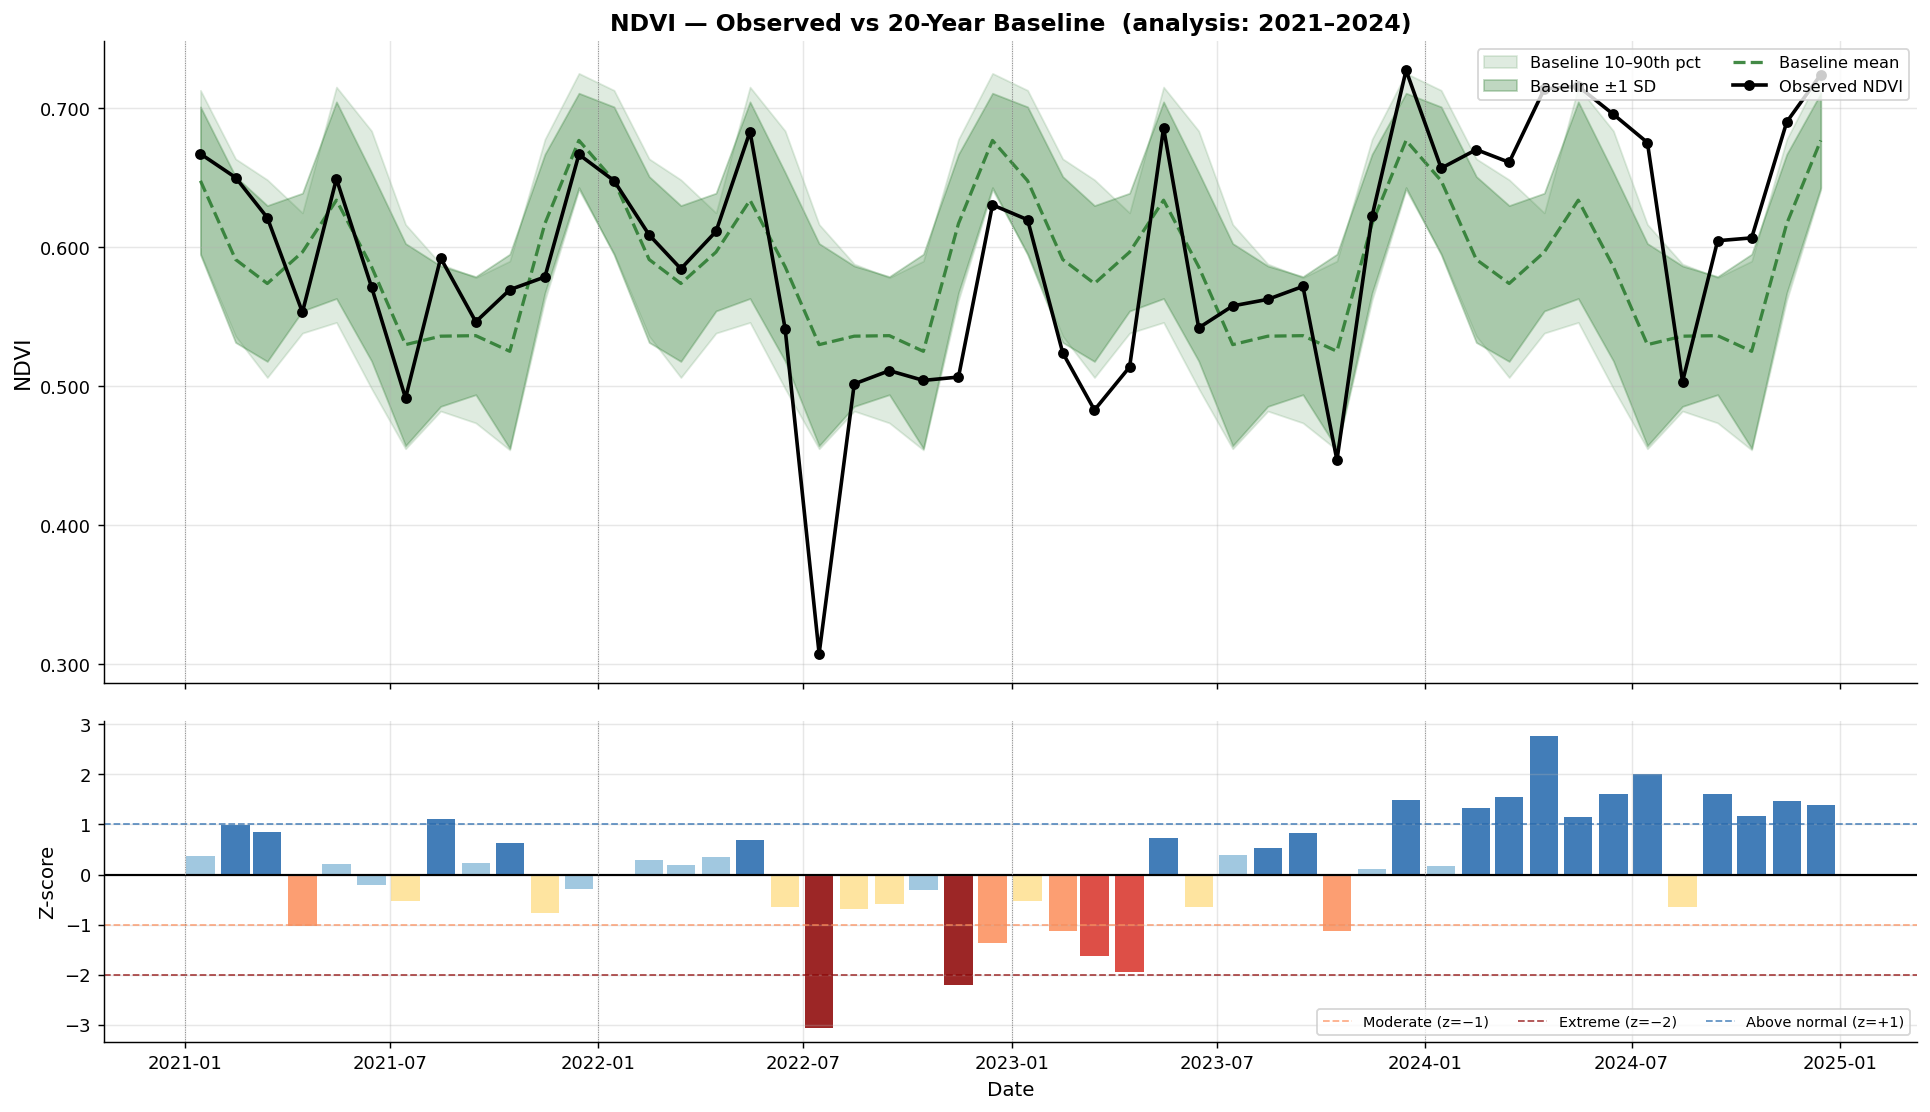

💾 Saved → baseline_outputs/anomalies/ndvi_anomaly_timeseries.png


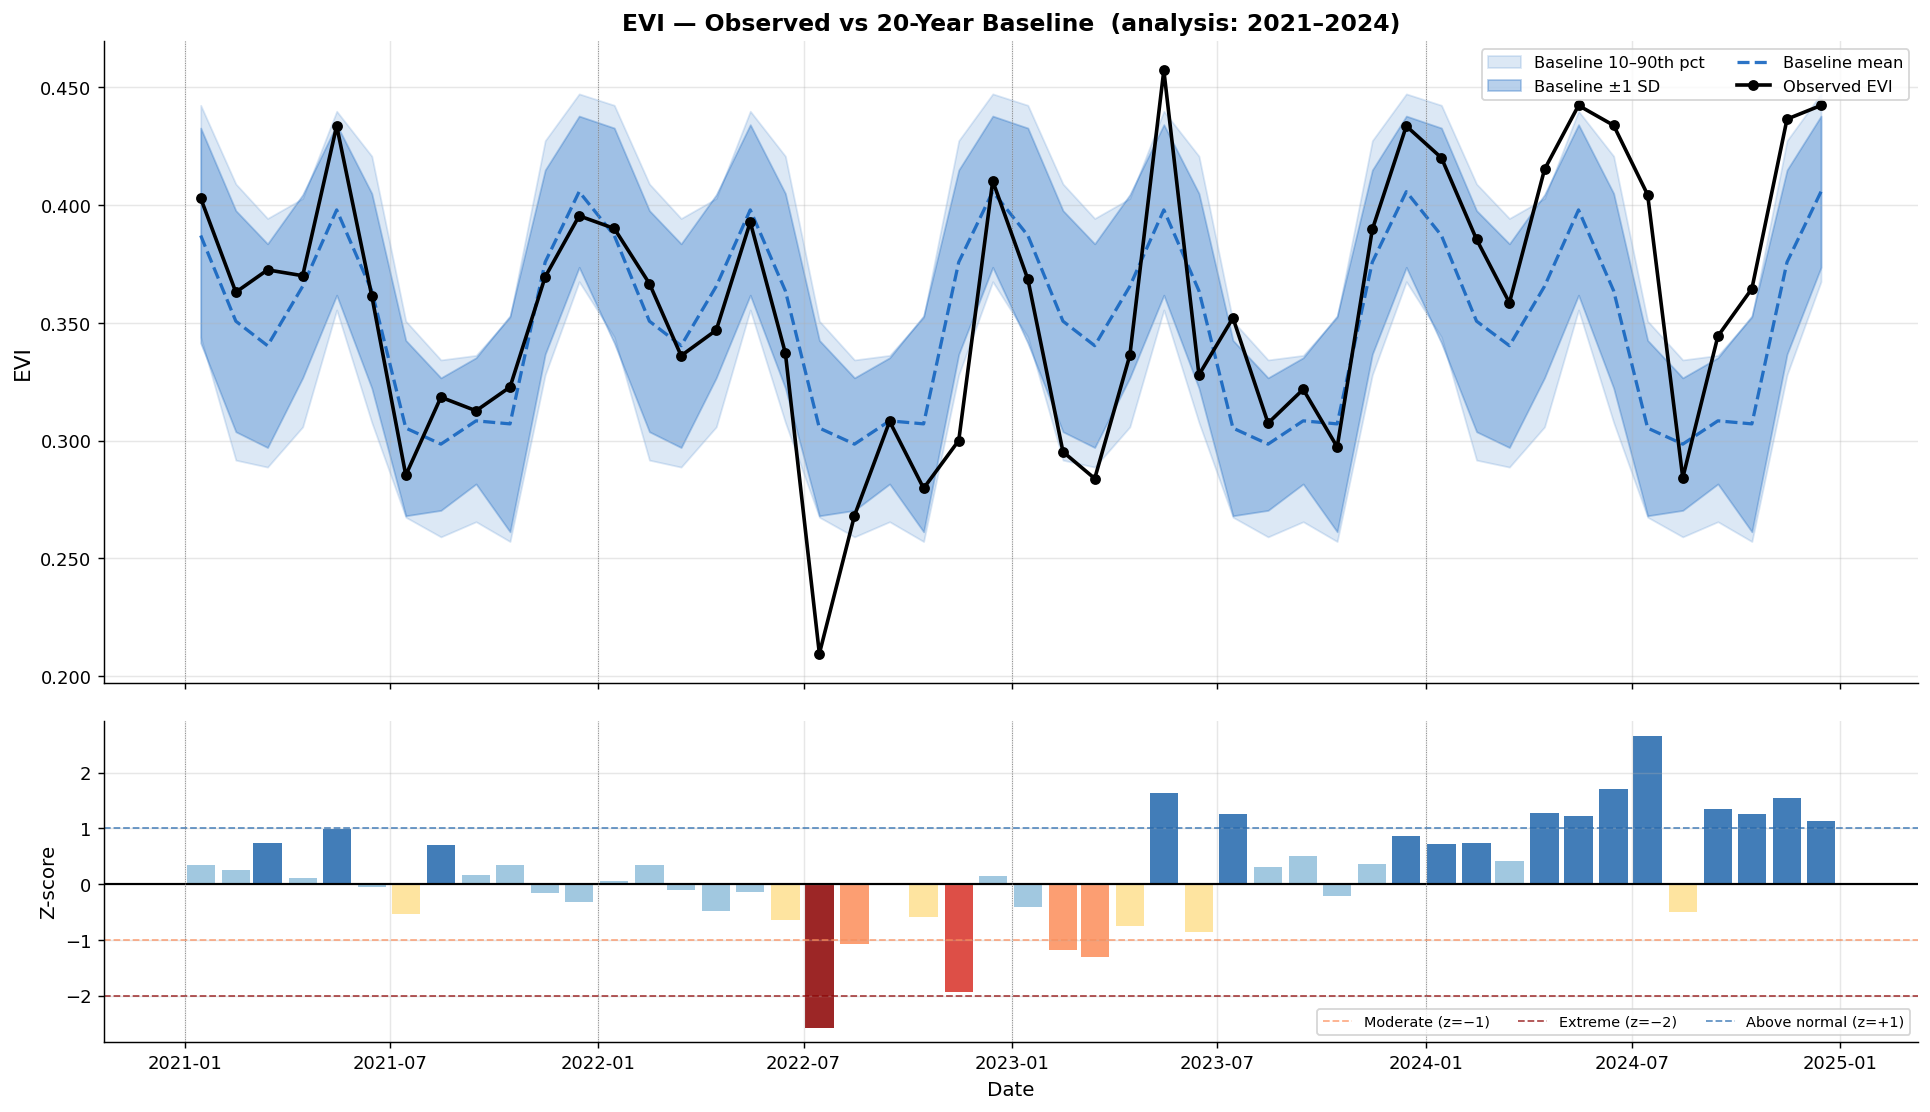

💾 Saved → baseline_outputs/anomalies/evi_anomaly_timeseries.png


In [19]:
# ── Fig 1: Anomaly time-series with baseline ribbon ───────────────────────────

def plot_anomaly_timeseries(df_anom, df_clim, index='ndvi'):
    fig = plt.figure(figsize=(18, 10))
    gs  = gridspec.GridSpec(2, 1, height_ratios=[2, 1], hspace=0.08)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1], sharex=ax1)

    idx_up = index.upper()
    clr    = '#2e7d32' if index == 'ndvi' else '#1565c0'

    # ── Top panel: observed vs baseline ─────────────────────────────────────
    dates  = df_anom['date']
    obs    = df_anom[f'{index}_mean']
    clim_m = df_anom[f'{index}_clim_mean']
    clim_s = df_anom[f'{index}_clim_std']
    p10    = df_anom[f'{index}_clim_p10']
    p90    = df_anom[f'{index}_clim_p90']

    ax1.fill_between(dates, p10, p90, alpha=0.15, color=clr, label='Baseline 10–90th pct')
    ax1.fill_between(dates, clim_m - clim_s, clim_m + clim_s,
                     alpha=0.30, color=clr, label='Baseline ±1 SD')
    ax1.plot(dates, clim_m, '--', color=clr, lw=1.8, alpha=0.9, label='Baseline mean')
    ax1.plot(dates, obs, 'o-', color='black', lw=2, ms=5, label=f'Observed {idx_up}', zorder=5)

    ax1.set_ylabel(idx_up, fontsize=12)
    ax1.set_title(f'{idx_up} — Observed vs 20-Year Baseline  '
                  f'(analysis: {df_anom.year.min()}–{df_anom.year.max()})',
                  fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9, ncol=2, loc='upper right')
    ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))
    plt.setp(ax1.get_xticklabels(), visible=False)

    # ── Bottom panel: Z-score anomaly bars ───────────────────────────────────
    zscore = df_anom[f'{index}_zscore']
    bar_colors = [DROUGHT_COLORS[classify_drought_zscore(z)] for z in zscore]

    ax2.bar(dates, zscore, width=25, color=bar_colors, alpha=0.85)
    ax2.axhline(0,  color='black', lw=1.2)
    ax2.axhline(-1, color=DROUGHT_COLORS['moderate'], lw=1, ls='--', alpha=0.7, label='Moderate (z=−1)')
    ax2.axhline(-2, color=DROUGHT_COLORS['extreme'],  lw=1, ls='--', alpha=0.7, label='Extreme (z=−2)')
    ax2.axhline( 1, color=DROUGHT_COLORS['above_normal'], lw=1, ls='--', alpha=0.7, label='Above normal (z=+1)')

    ax2.set_ylabel('Z-score', fontsize=11)
    ax2.set_xlabel('Date',    fontsize=11)
    ax2.legend(fontsize=8, loc='lower right', ncol=3)

    # Year separators
    for yr in df_anom.year.unique():
        ax1.axvline(pd.Timestamp(yr, 1, 1), color='grey', lw=0.5, ls=':')
        ax2.axvline(pd.Timestamp(yr, 1, 1), color='grey', lw=0.5, ls=':')

    plt.tight_layout()
    out = Path(CONFIG['output_dir'])/'anomalies'/f'{index}_anomaly_timeseries.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved → {out}")

plot_anomaly_timeseries(df_anom, df_clim, 'ndvi')
plot_anomaly_timeseries(df_anom, df_clim, 'evi')

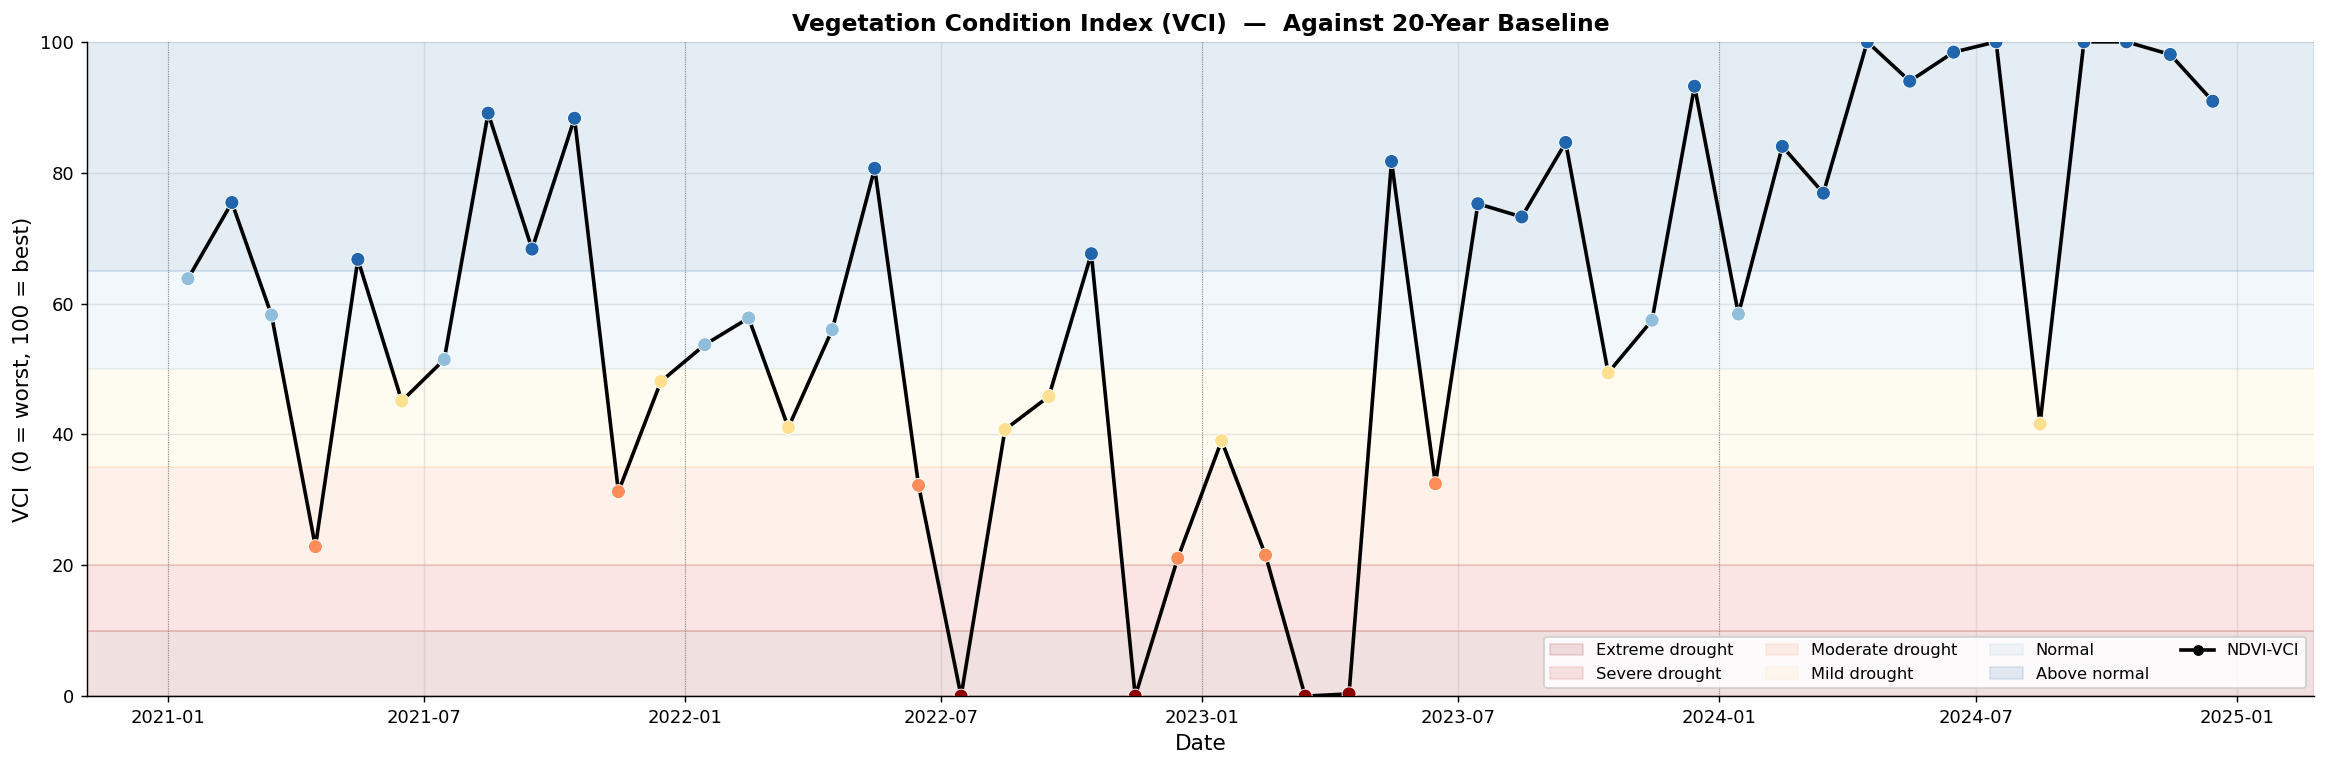

💾 Saved → baseline_outputs/drought/vci_timeseries.png


In [20]:
# ── Fig 2: VCI time-series with drought threshold bands ───────────────────────

fig, ax = plt.subplots(figsize=(18, 6))

# Drought threshold bands
thresholds = [
    (0,  10,  DROUGHT_COLORS['extreme'],    'Extreme drought'),
    (10, 20,  DROUGHT_COLORS['severe'],     'Severe drought'),
    (20, 35,  DROUGHT_COLORS['moderate'],   'Moderate drought'),
    (35, 50,  DROUGHT_COLORS['mild'],       'Mild drought'),
    (50, 65,  DROUGHT_COLORS['normal'],     'Normal'),
    (65, 100, DROUGHT_COLORS['above_normal'],'Above normal'),
]
for lo, hi, clr, lbl in thresholds:
    ax.axhspan(lo, hi, alpha=0.12, color=clr, label=lbl)

# VCI line
ax.plot(df_anom['date'], df_anom['ndvi_vci'],
        'o-', color='black', lw=2, ms=5, zorder=5, label='NDVI-VCI')

# Colour-coded scatter on top
scatter_colors = [DROUGHT_COLORS[c] for c in df_anom['drought_class_vci']]
ax.scatter(df_anom['date'], df_anom['ndvi_vci'],
           c=scatter_colors, s=60, zorder=6, edgecolors='white', linewidths=0.5)

# Year separators
for yr in df_anom.year.unique():
    ax.axvline(pd.Timestamp(yr, 1, 1), color='grey', lw=0.5, ls=':')

ax.set_ylim(0, 100)
ax.set_ylabel('VCI  (0 = worst, 100 = best)', fontsize=12)
ax.set_xlabel('Date', fontsize=12)
ax.set_title('Vegetation Condition Index (VCI)  —  Against 20-Year Baseline',
             fontsize=13, fontweight='bold')

# Clean legend (threshold classes + VCI line)
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, labels, fontsize=9, ncol=4, loc='lower right',
          framealpha=0.85)

plt.tight_layout()
out = Path(CONFIG['output_dir'])/'drought'/'vci_timeseries.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {out}")

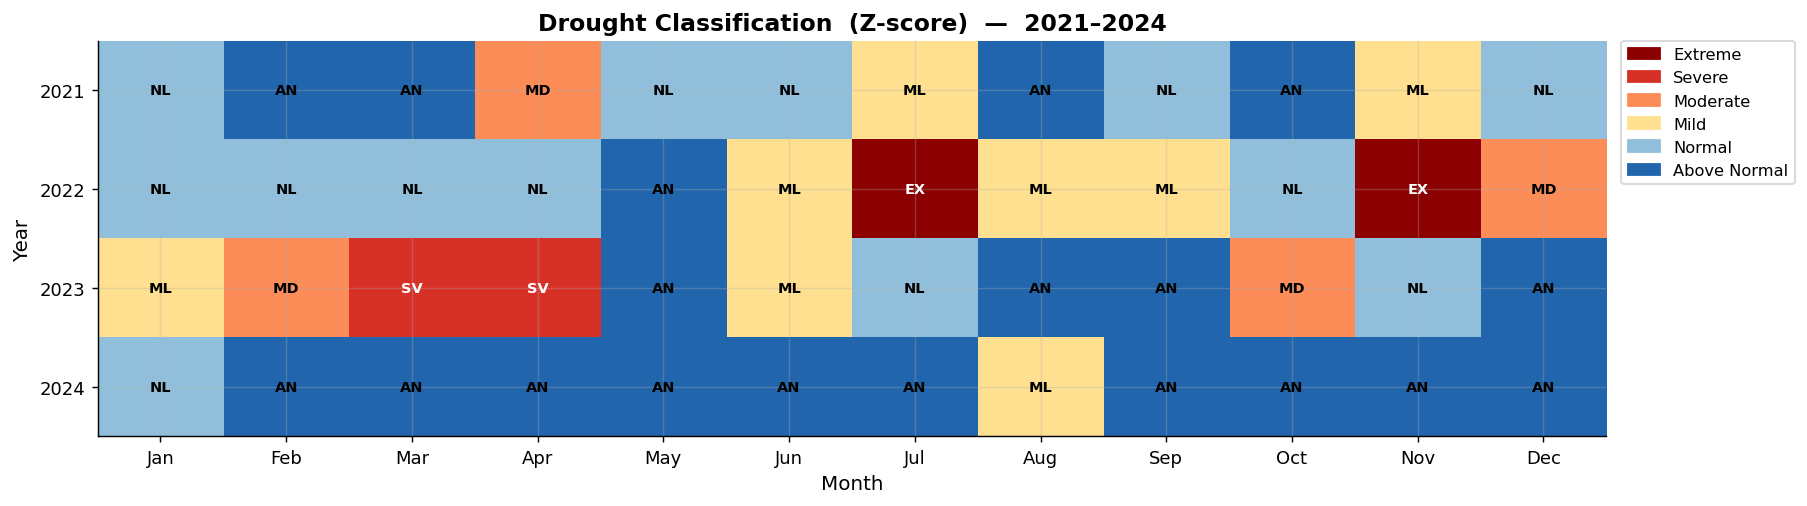

💾 Saved → baseline_outputs/drought/drought_heatmap_zscore.png


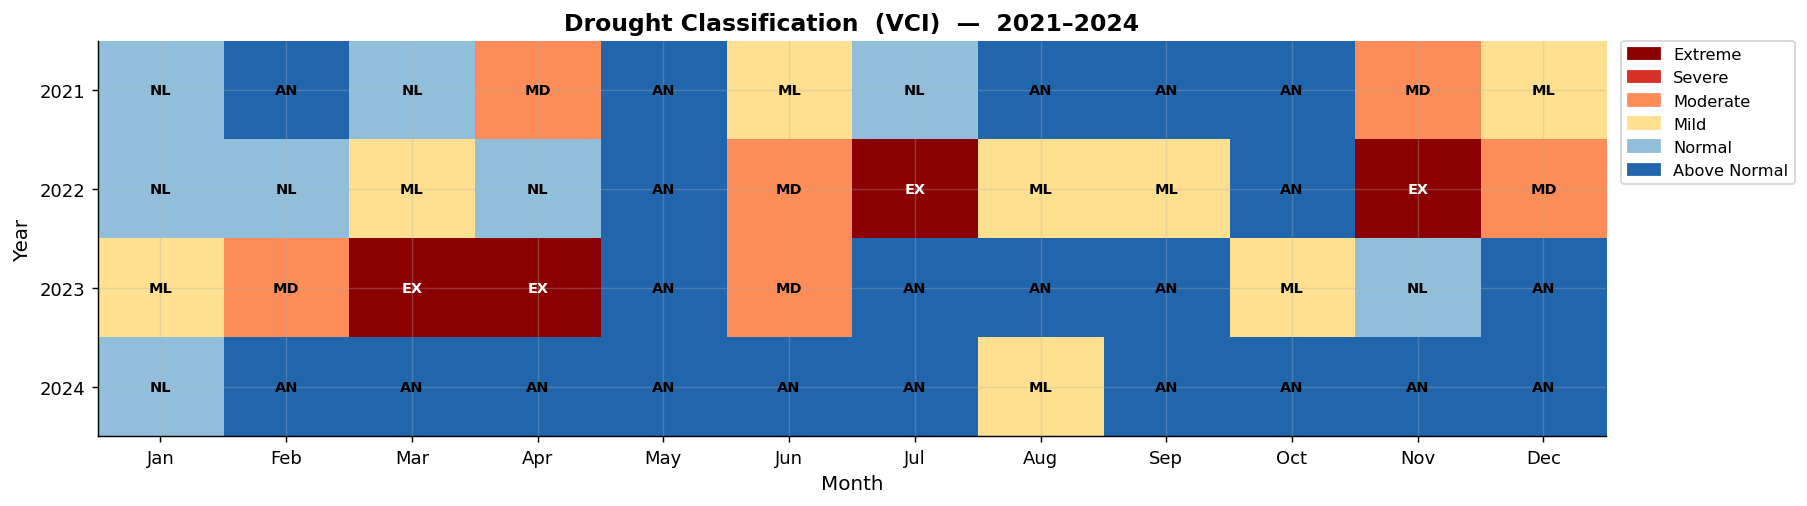

💾 Saved → baseline_outputs/drought/drought_heatmap_vci.png


In [21]:
# ── Fig 3: Drought classification heatmap (year × month) ─────────────────────

CLASS_ORDER = ['extreme','severe','moderate','mild','normal','above_normal']
CLASS_INT   = {c: i for i, c in enumerate(CLASS_ORDER)}
CMAP        = mcolors.ListedColormap([DROUGHT_COLORS[c] for c in CLASS_ORDER])
NORM        = mcolors.BoundaryNorm(range(len(CLASS_ORDER) + 1), CMAP.N)

for method, col in [('Z-score', 'drought_class_zscore'), ('VCI', 'drought_class_vci')]:
    pivot = (df_anom
             .pivot_table(index='year', columns='month',
                          values=col, aggfunc='first')
             .applymap(lambda x: CLASS_INT.get(x, np.nan)))

    fig, ax = plt.subplots(figsize=(14, max(4, len(pivot) * 0.55 + 1)))

    im = ax.imshow(pivot.values, cmap=CMAP, norm=NORM,
                   aspect='auto', interpolation='nearest')

    # Annotations
    for i, yr in enumerate(pivot.index):
        for j, mo in enumerate(pivot.columns):
            val = pivot.loc[yr, mo]
            if not np.isnan(val):
                cls = CLASS_ORDER[int(val)]
                short = {'extreme':'EX','severe':'SV','moderate':'MD',
                         'mild':'ML','normal':'NL','above_normal':'AN'}[cls]
                ax.text(j, i, short, ha='center', va='center',
                        fontsize=8, fontweight='bold',
                        color='white' if val <= 1 else 'black')

    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_ABBR, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index.astype(str), fontsize=10)
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Year', fontsize=11)
    ax.set_title(f'Drought Classification  ({method})  —  '
                 f'{df_anom.year.min()}–{df_anom.year.max()}',
                 fontsize=13, fontweight='bold')

    # Colourbar legend
    patches = [mpatches.Patch(color=DROUGHT_COLORS[c], label=c.replace('_',' ').title())
               for c in CLASS_ORDER]
    ax.legend(handles=patches, fontsize=9, bbox_to_anchor=(1.01, 1),
              loc='upper left', borderaxespad=0)

    plt.tight_layout()
    fname = method.lower().replace('-','').replace(' ','_')
    out   = Path(CONFIG['output_dir'])/'drought'/f'drought_heatmap_{fname}.png'
    fig.savefig(out, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"💾 Saved → {out}")

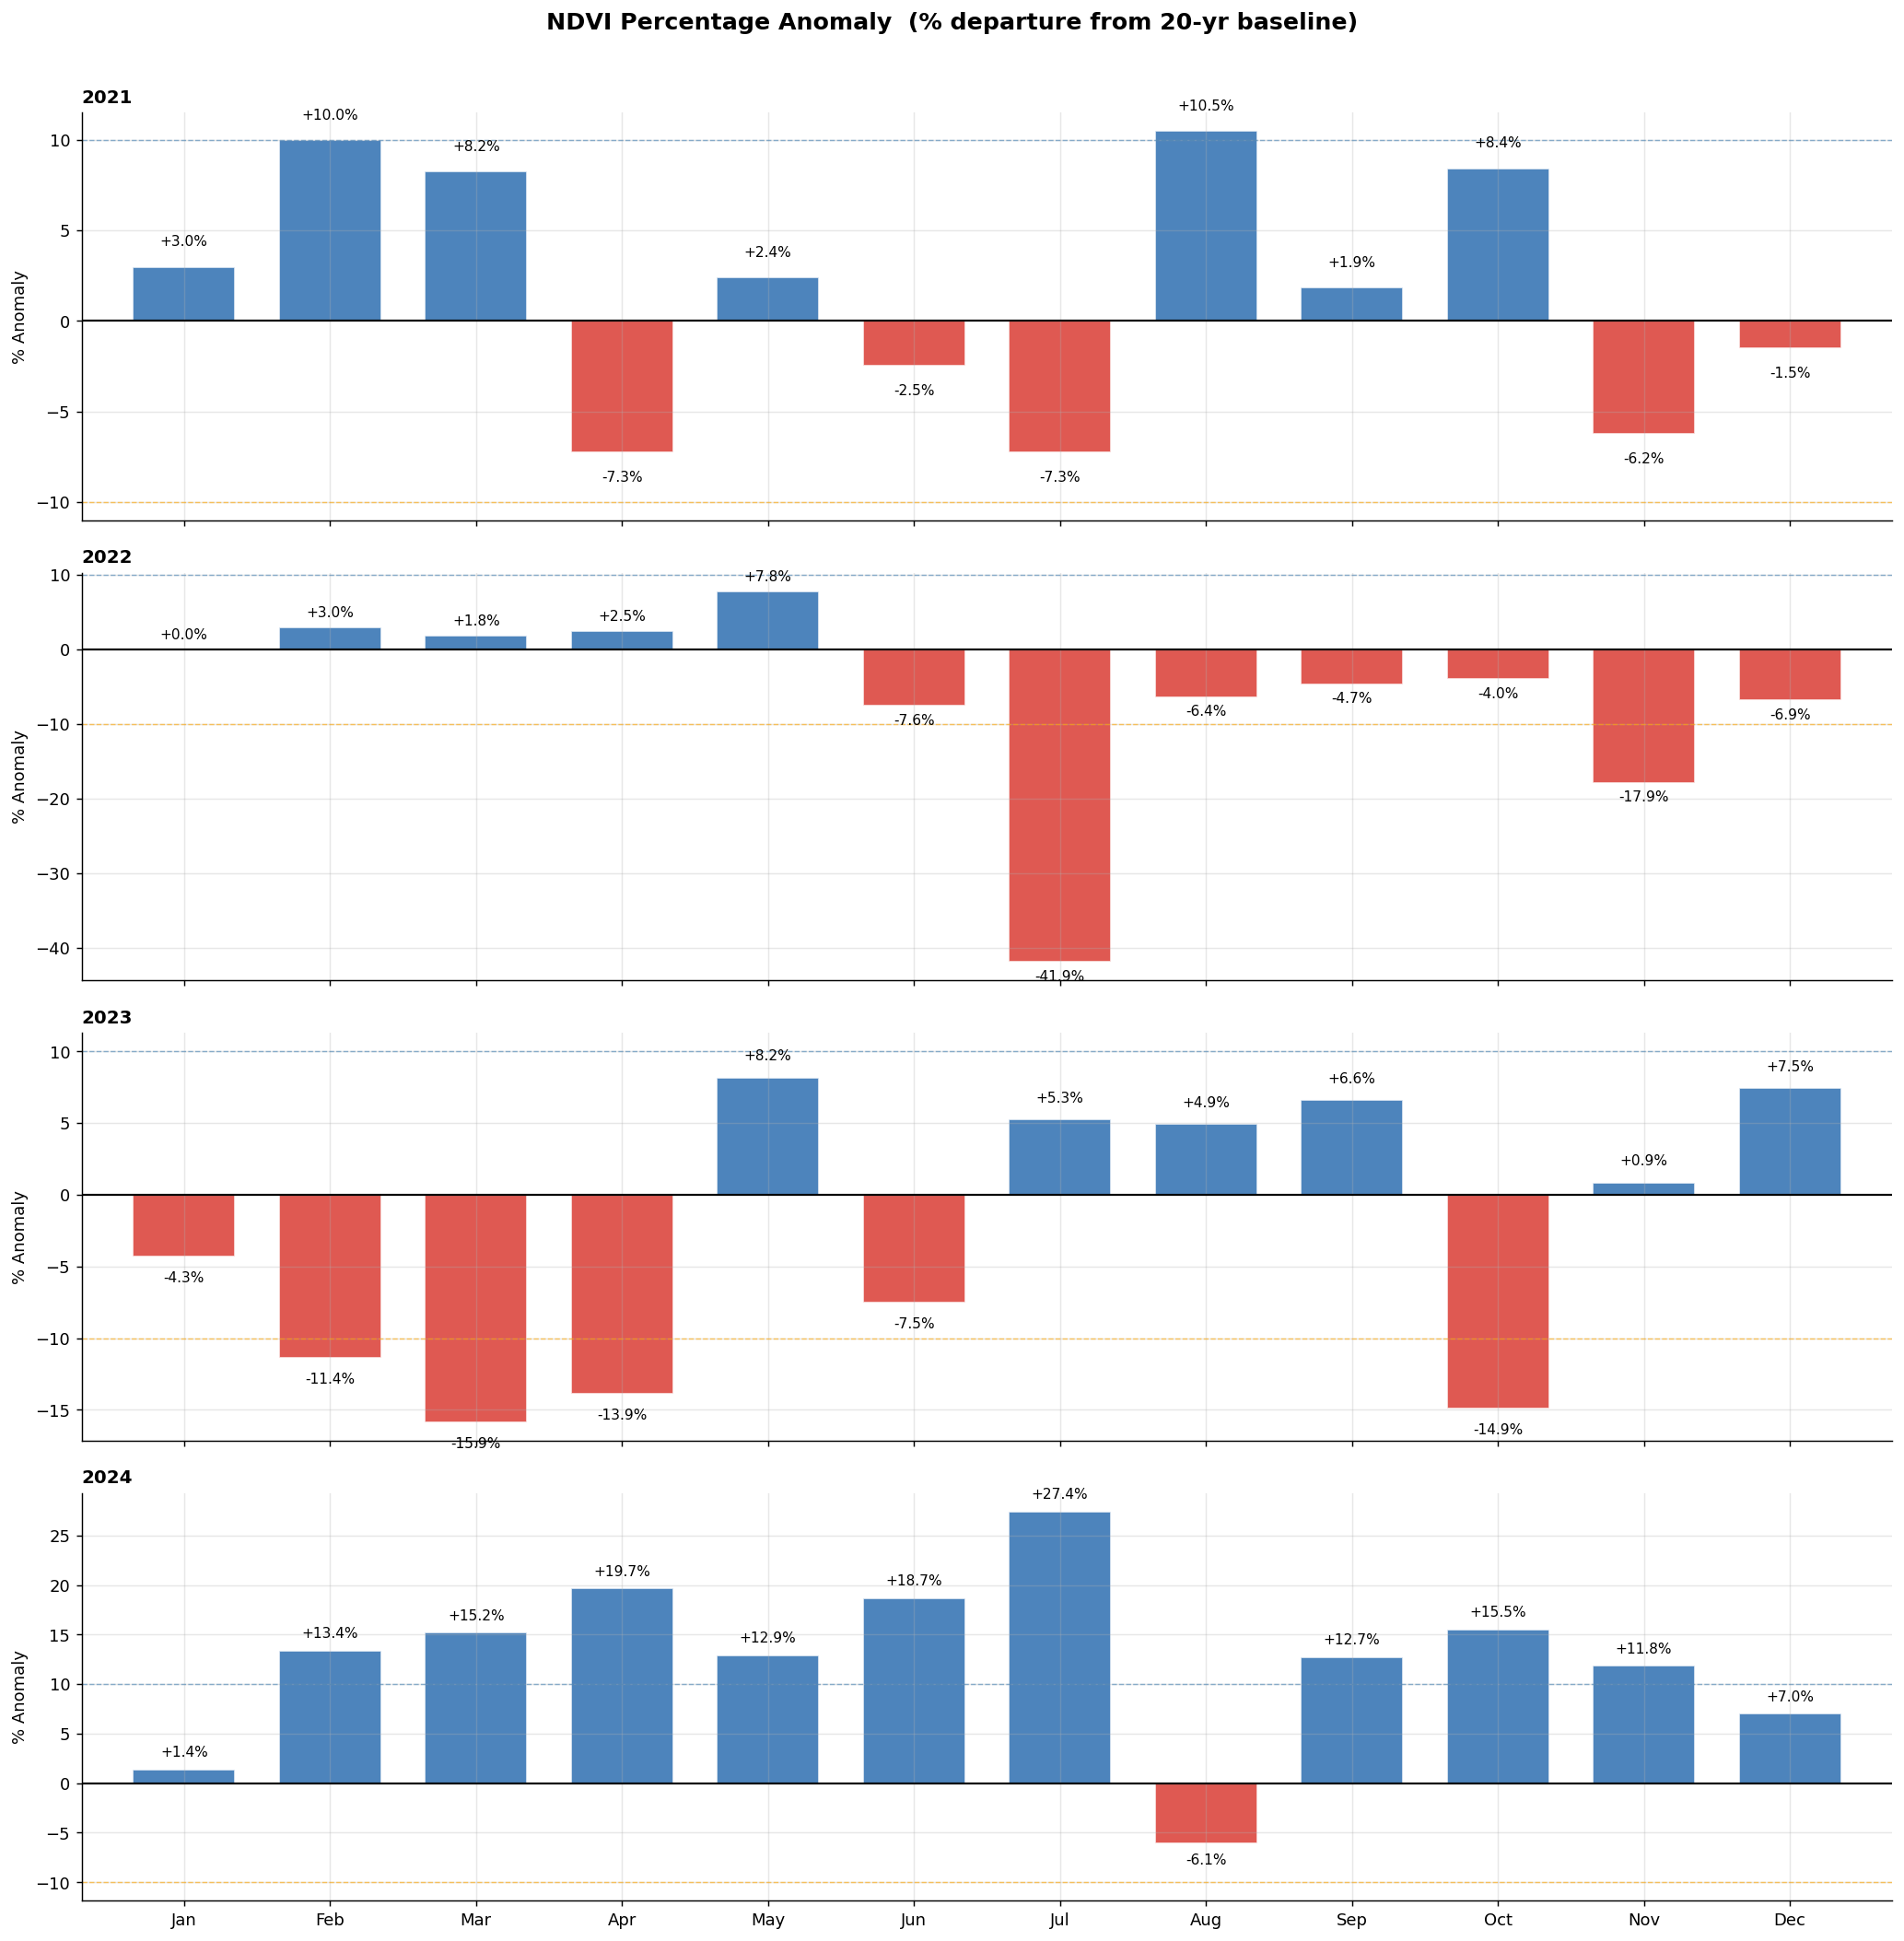

💾 Saved → baseline_outputs/anomalies/ndvi_pct_anomaly_bars.png


In [22]:
# ── Fig 4: Percentage anomaly bars by year & month ────────────────────────────

fig, axes = plt.subplots(len(CONFIG['analysis_years']), 1,
                         figsize=(16, 4 * len(CONFIG['analysis_years'])),
                         sharex=True)

if len(CONFIG['analysis_years']) == 1:
    axes = [axes]

fig.suptitle('NDVI Percentage Anomaly  (% departure from 20-yr baseline)',
             fontsize=14, fontweight='bold', y=1.01)

for ax, yr in zip(axes, CONFIG['analysis_years']):
    sub  = df_anom[df_anom.year == yr].copy()
    vals = sub['ndvi_pct_anomaly'].values
    mths = sub['month'].values
    clrs = ['#D73027' if v < 0 else '#2166AC' for v in vals]

    bars = ax.bar(mths, vals, color=clrs, alpha=0.80, width=0.7, edgecolor='white')
    ax.axhline(0, color='black', lw=1.2)
    ax.axhline(-10, color='orange', lw=0.8, ls='--', alpha=0.6)
    ax.axhline( 10, color='steelblue', lw=0.8, ls='--', alpha=0.6)

    # Value labels on bars
    for bar, val in zip(bars, vals):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2,
                    val + (1 if val >= 0 else -1),
                    f'{val:+.1f}%',
                    ha='center', va='bottom' if val >= 0 else 'top',
                    fontsize=8.5)

    ax.set_ylabel('% Anomaly', fontsize=10)
    ax.set_title(str(yr), fontsize=11, loc='left', fontweight='bold')
    ax.set_xlim(0.3, 12.7)

axes[-1].set_xticks(range(1, 13))
axes[-1].set_xticklabels(MONTH_ABBR, fontsize=10)

plt.tight_layout()
out = Path(CONFIG['output_dir'])/'anomalies'/'ndvi_pct_anomaly_bars.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {out}")

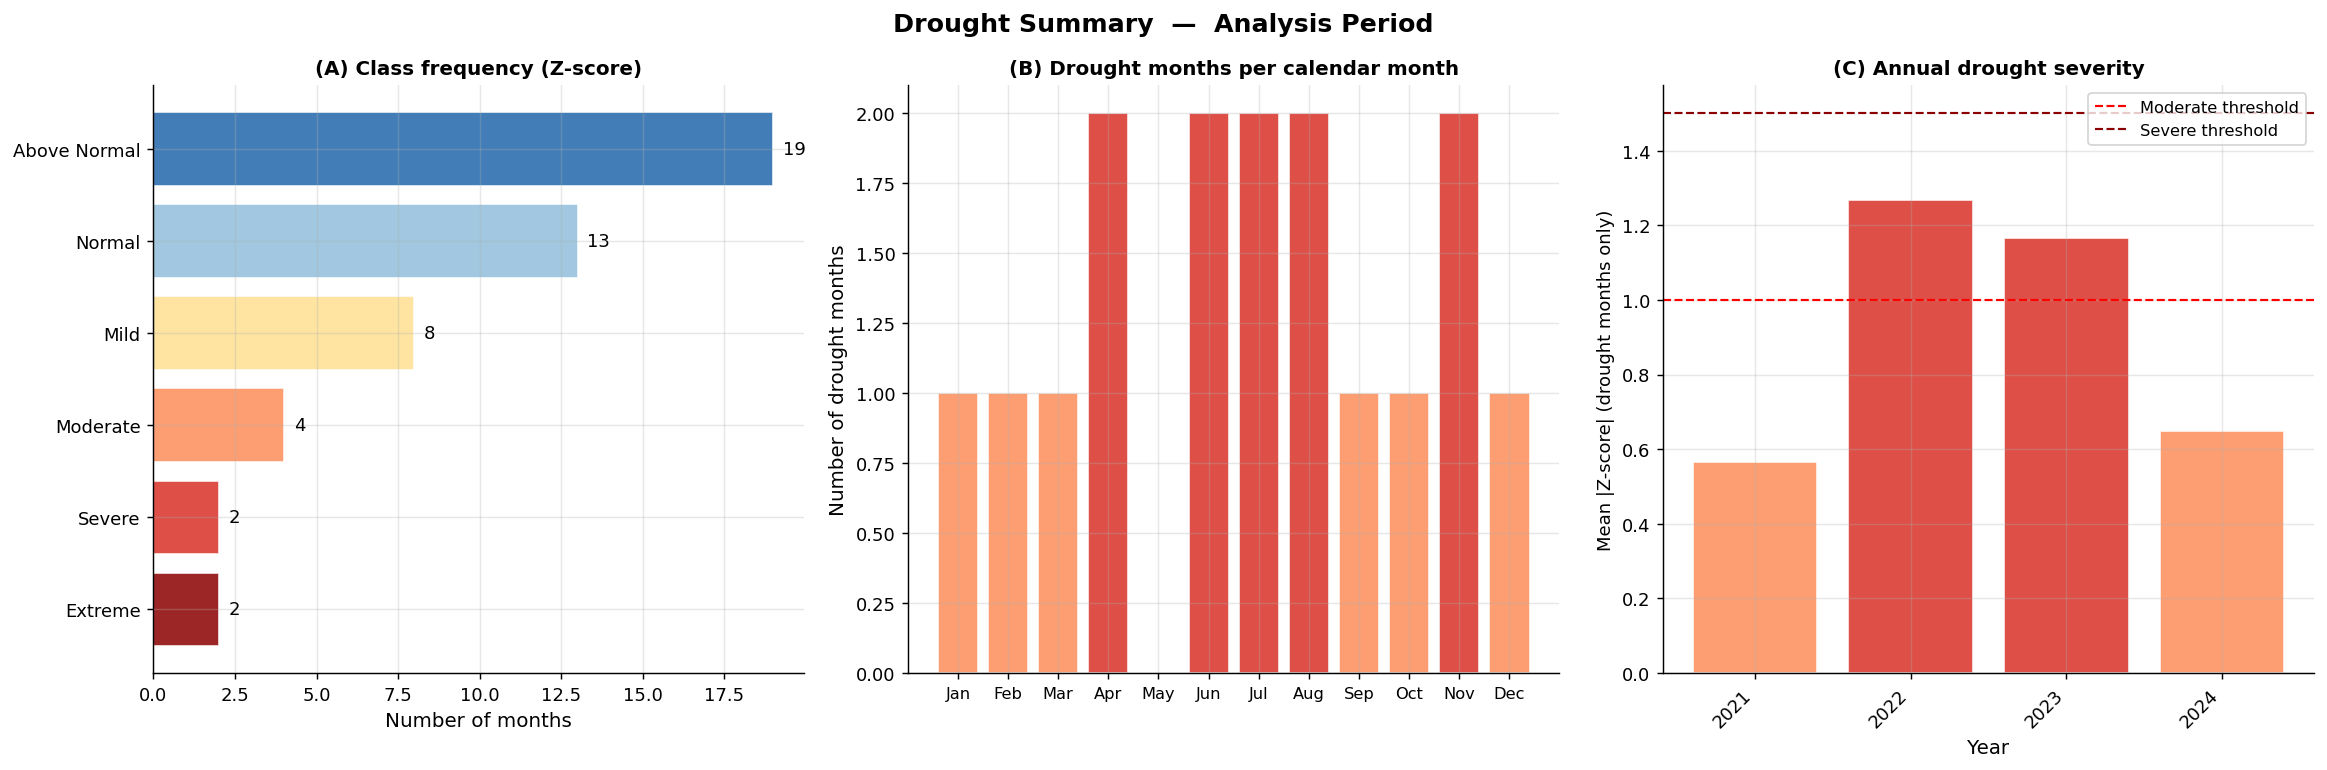

💾 Saved → baseline_outputs/drought/drought_summary.png


In [23]:
# ── Fig 5: Drought frequency & severity summary ───────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Drought Summary  —  Analysis Period',
             fontsize=14, fontweight='bold')

# Panel A: Frequency of each class
ax = axes[0]
freq = (df_anom['drought_class_zscore']
        .value_counts()
        .reindex(CLASS_ORDER, fill_value=0))

bars = ax.barh(freq.index, freq.values,
               color=[DROUGHT_COLORS[c] for c in freq.index],
               edgecolor='white', alpha=0.85)
for bar, val in zip(bars, freq.values):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=10)
ax.set_xlabel('Number of months', fontsize=11)
ax.set_title('(A) Class frequency (Z-score)', fontsize=11, fontweight='bold')
ax.set_yticklabels([c.replace('_',' ').title() for c in freq.index], fontsize=10)

# Panel B: Monthly drought frequency (how often each month is in drought)
ax = axes[1]
drought_months = df_anom[df_anom['drought_class_zscore'].isin(
    ['extreme','severe','moderate','mild'])]
month_freq = (drought_months
              .groupby('month').size()
              .reindex(range(1, 13), fill_value=0))

clrs_bar = ['#D73027' if v >= 2 else '#FC8D59' if v == 1 else '#91BFDB'
            for v in month_freq.values]
ax.bar(range(1, 13), month_freq.values,
       color=clrs_bar, alpha=0.85, edgecolor='white')
ax.set_xticks(range(1, 13))
ax.set_xticklabels(MONTH_ABBR, fontsize=9)
ax.set_ylabel('Number of drought months', fontsize=11)
ax.set_title('(B) Drought months per calendar month', fontsize=11, fontweight='bold')

# Panel C: Annual drought score (mean absolute Z-score)
ax = axes[2]
annual_severity = (df_anom.groupby('year')['ndvi_zscore']
                   .apply(lambda x: x[x < 0].abs().mean())
                   .fillna(0))

bar_clrs = ['#8B0000' if v > 1.5 else '#D73027' if v > 1.0 else '#FC8D59'
            if v > 0.5 else '#91BFDB' for v in annual_severity.values]
ax.bar(annual_severity.index, annual_severity.values,
       color=bar_clrs, alpha=0.85, edgecolor='white')
ax.axhline(1.0, color='red',    lw=1.2, ls='--', label='Moderate threshold')
ax.axhline(1.5, color='darkred',lw=1.2, ls='--', label='Severe threshold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Mean |Z-score| (drought months only)', fontsize=10)
ax.set_title('(C) Annual drought severity', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.set_xticks(annual_severity.index)
ax.set_xticklabels(annual_severity.index.astype(str), rotation=45, ha='right')

plt.tight_layout()
out = Path(CONFIG['output_dir'])/'drought'/'drought_summary.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {out}")

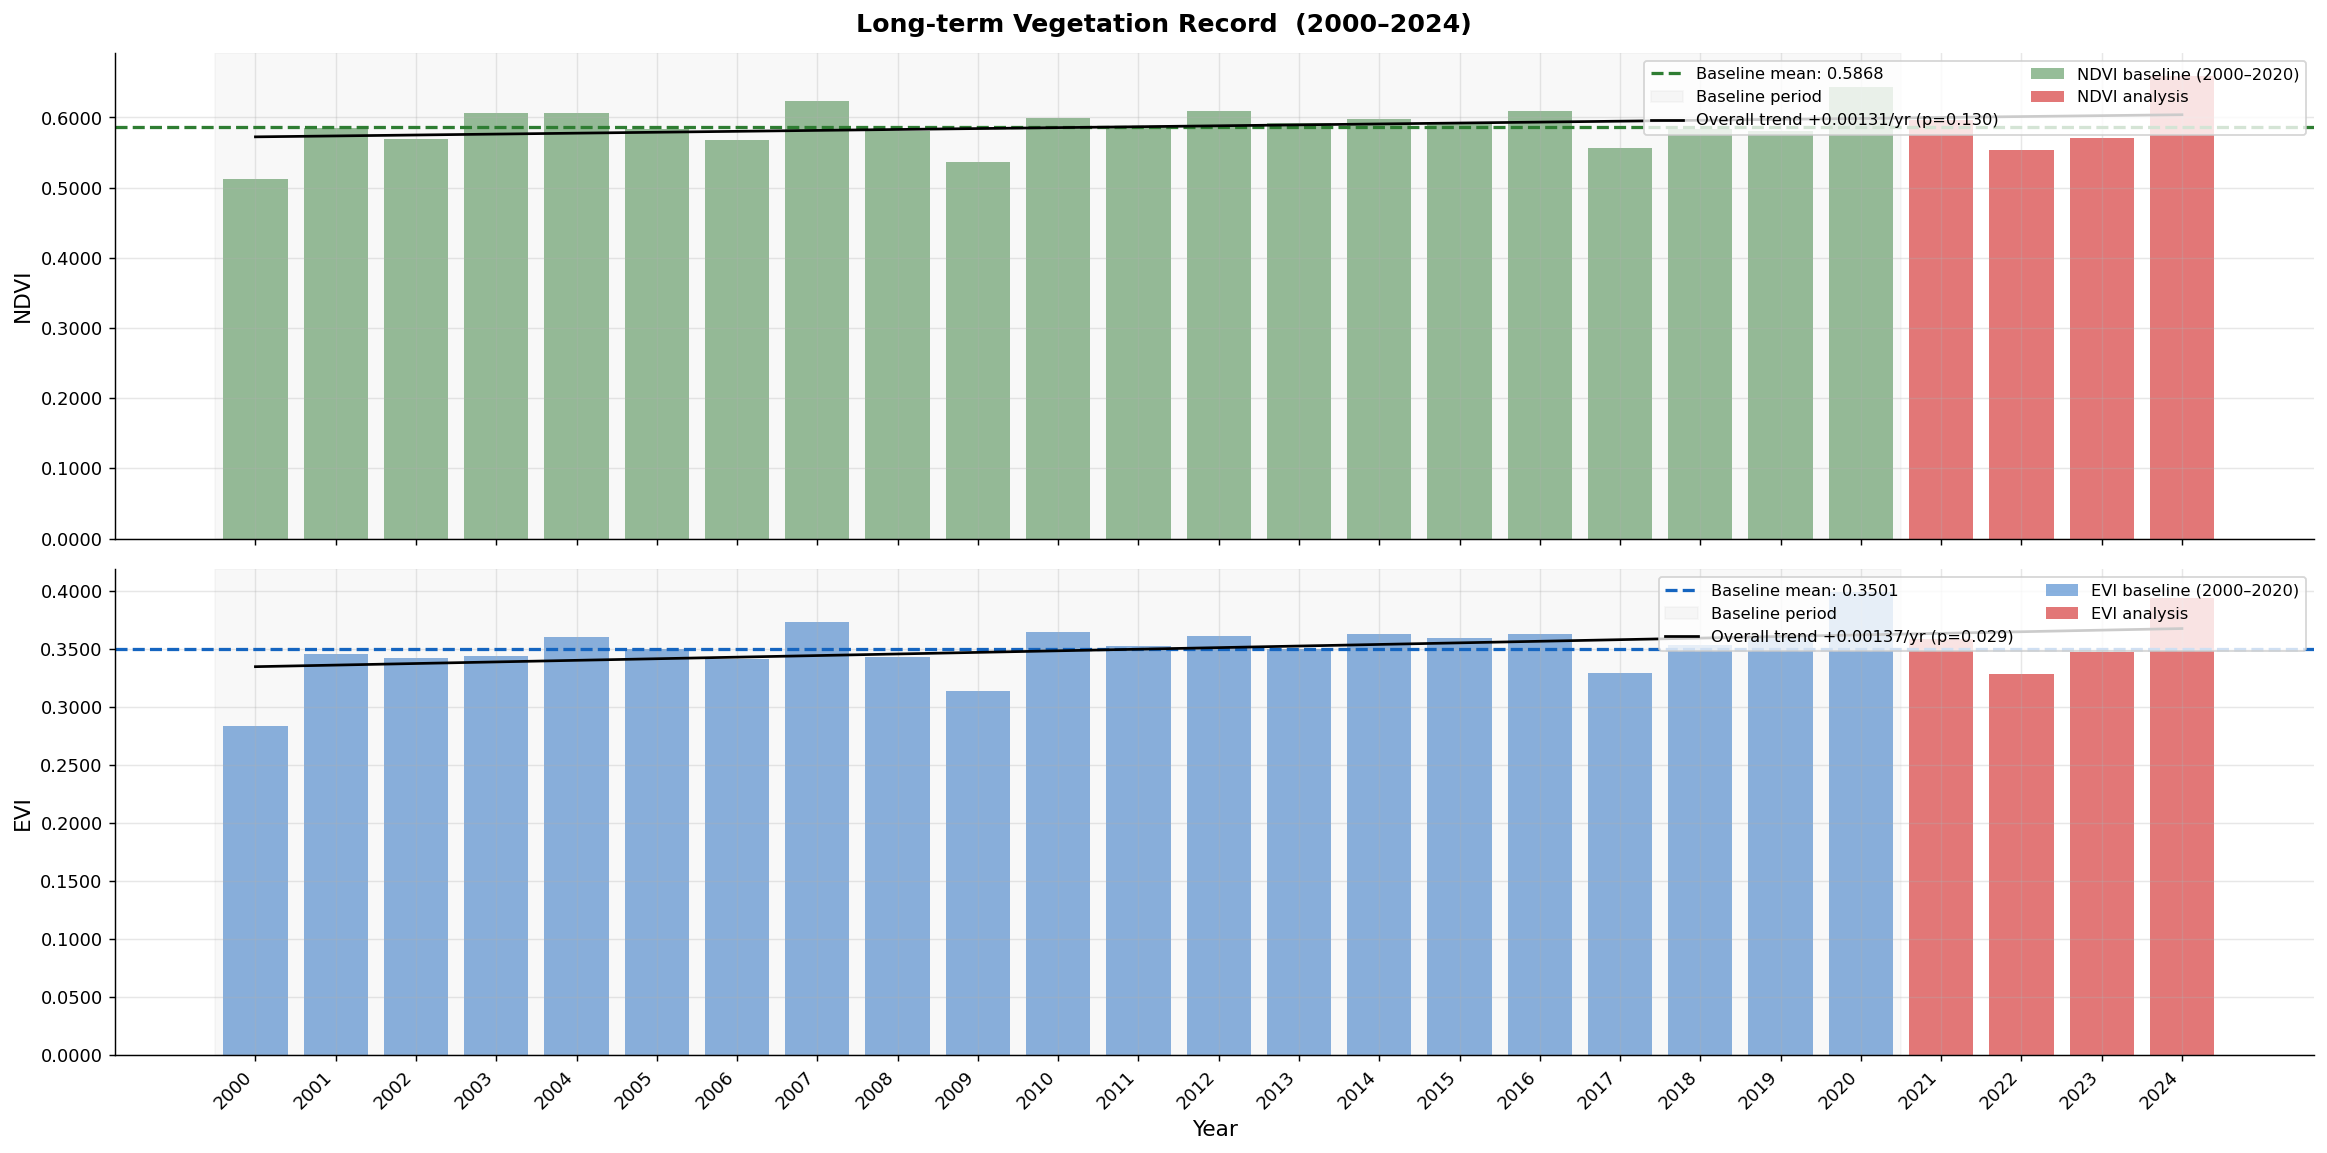

💾 Saved → baseline_outputs/trends/longterm_combined.png


In [24]:
# ── Fig 6: Full long-term view  (baseline + analysis combined) ────────────────

df_full = pd.concat([
    df_baseline_raw.assign(period='baseline'),
    df_analysis.assign(period='analysis')
], ignore_index=True).sort_values('date').reset_index(drop=True)

# Annual means
ann = (df_full.dropna(subset=['ndvi_mean','evi_mean'])
       .groupby(['year','period'])[['ndvi_mean','evi_mean']]
       .mean().reset_index())

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
fig.suptitle(f'Long-term Vegetation Record  '
             f'({CONFIG["baseline_start"]}–{df_full.year.max()})',
             fontsize=14, fontweight='bold')

for ax, col, clr, label in zip(
        axes,
        ['ndvi_mean','evi_mean'],
        ['#2e7d32','#1565c0'],
        ['NDVI','EVI']):

    base_sub = ann[ann.period=='baseline']
    anal_sub = ann[ann.period=='analysis']

    ax.bar(base_sub.year, base_sub[col], width=0.8,
           color=clr, alpha=0.50, label=f'{label} baseline (2000–2020)')
    ax.bar(anal_sub.year, anal_sub[col], width=0.8,
           color='#d32f2f', alpha=0.65, label=f'{label} analysis')

    # Baseline mean reference line
    bline = base_sub[col].mean()
    ax.axhline(bline, color=clr, lw=1.8, ls='--',
               label=f'Baseline mean: {bline:.4f}')

    # Shade baseline / analysis regions
    ax.axvspan(CONFIG['baseline_start'] - 0.5,
               CONFIG['baseline_end'] + 0.5,
               alpha=0.05, color='grey', label='Baseline period')

    # OLS trend across entire record
    x_all = ann.year.values
    y_all = ann[col].values
    mask  = ~np.isnan(y_all)
    slope, intercept, r, p, _ = scipy_stats.linregress(x_all[mask], y_all[mask])
    ax.plot(x_all[mask], slope * x_all[mask] + intercept,
            '-', color='black', lw=1.5,
            label=f'Overall trend {slope:+.5f}/yr (p={p:.3f})')

    ax.set_ylabel(label, fontsize=12)
    ax.legend(fontsize=9, ncol=2, loc='upper right')
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.4f'))

axes[-1].set_xlabel('Year', fontsize=12)
axes[-1].set_xticks(ann.year.unique())
axes[-1].set_xticklabels(ann.year.unique().astype(str), rotation=45, ha='right')

plt.tight_layout()
out = Path(CONFIG['output_dir'])/'trends'/'longterm_combined.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {out}")

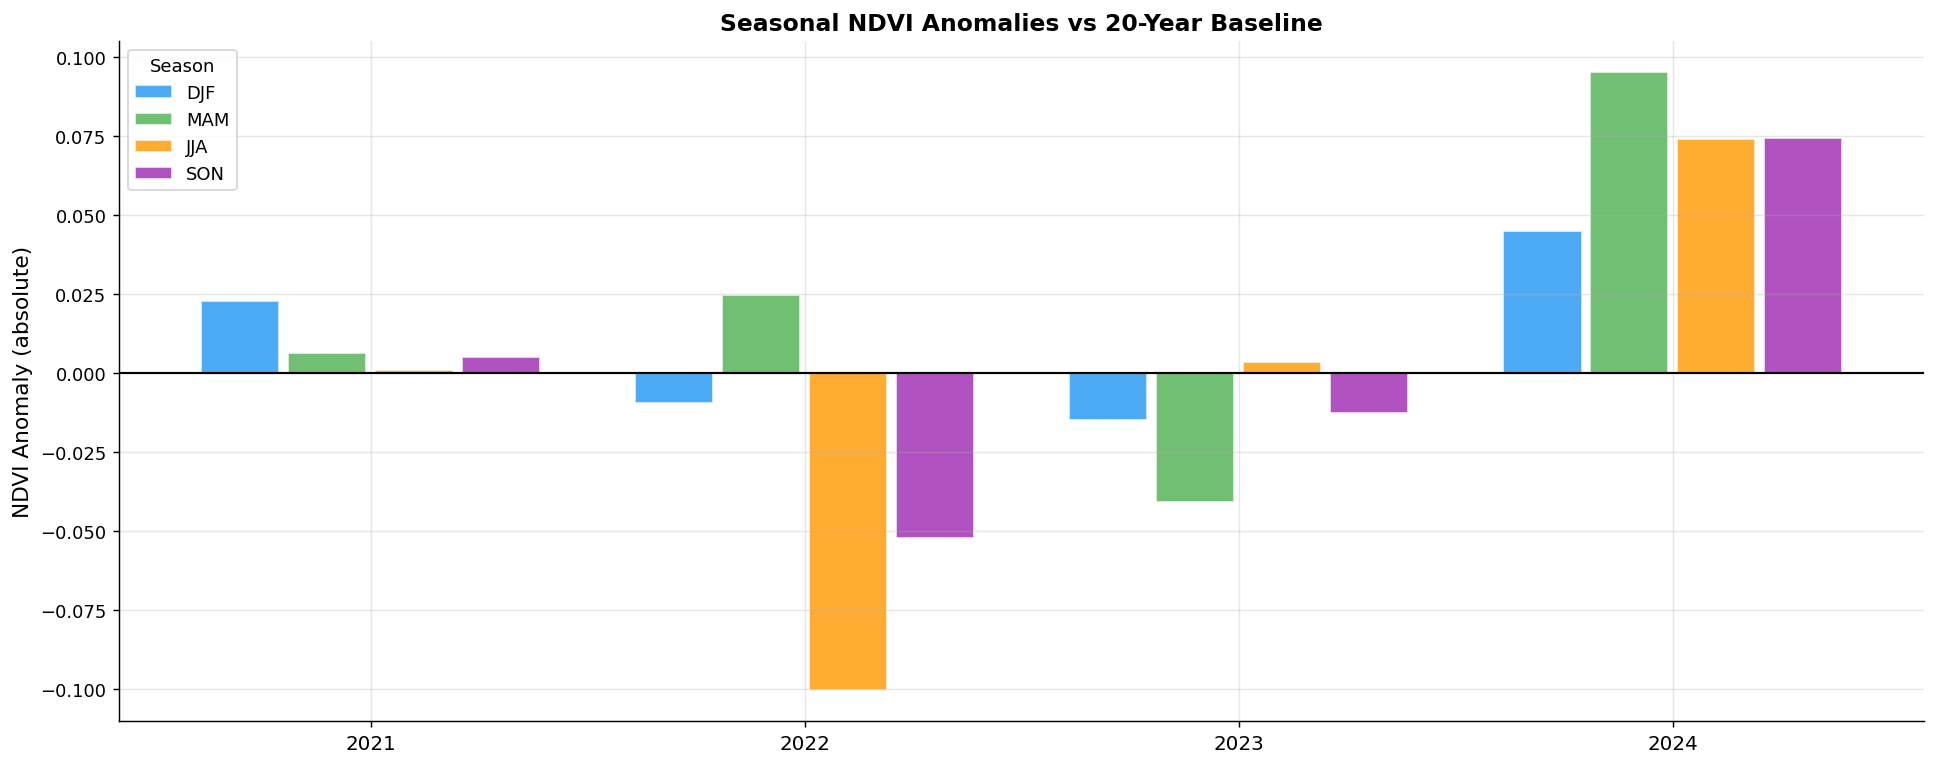

💾 Saved → baseline_outputs/anomalies/seasonal_anomaly.png


In [25]:
# ── Fig 7: Seasonal anomaly breakdown per analysis year ───────────────────────

seasons = {
    'DJF': [12, 1, 2],
    'MAM': [3, 4, 5],
    'JJA': [6, 7, 8],
    'SON': [9, 10, 11],
}

def season_of(month):
    for s, months in seasons.items():
        if month in months:
            return s
    return 'Unknown'

df_anom['season'] = df_anom['month'].apply(season_of)
seas_anom = (df_anom
             .groupby(['year','season'])[['ndvi_anomaly','ndvi_zscore','ndvi_vci']]
             .mean()
             .reset_index())

fig, ax = plt.subplots(figsize=(15, 6))

season_offsets = {'DJF': -0.3, 'MAM': -0.1, 'JJA': 0.1, 'SON': 0.3}
season_colors  = {'DJF': '#2196F3', 'MAM': '#4CAF50',
                  'JJA': '#FF9800', 'SON': '#9C27B0'}
bar_w = 0.18

for sname, offset in season_offsets.items():
    sub  = seas_anom[seas_anom.season == sname]
    xpos = sub.year.values + offset
    vals = sub.ndvi_anomaly.values
    clrs = ['#D73027' if v < 0 else '#2166AC' for v in vals]

    ax.bar(xpos, vals, width=bar_w,
           color=season_colors[sname], alpha=0.80, label=sname, edgecolor='white')

ax.axhline(0, color='black', lw=1.2)
ax.set_xticks(CONFIG['analysis_years'])
ax.set_xticklabels([str(y) for y in CONFIG['analysis_years']], fontsize=11)
ax.set_ylabel('NDVI Anomaly (absolute)', fontsize=12)
ax.set_title('Seasonal NDVI Anomalies vs 20-Year Baseline',
             fontsize=13, fontweight='bold')
ax.legend(title='Season', fontsize=10, title_fontsize=10)

plt.tight_layout()
out = Path(CONFIG['output_dir'])/'anomalies'/'seasonal_anomaly.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Saved → {out}")

## 9 · Drought Summary Table

In [26]:
# ── Drought event catalogue ────────────────────────────────────────────────────
from IPython.display import HTML

drought_events = df_anom[
    df_anom['drought_class_zscore'].isin(['extreme','severe','moderate'])
].copy()

drought_events['month_name'] = drought_events['month'].apply(
    lambda m: MONTH_ABBR[m - 1])

display_cols = {
    'year'              : 'Year',
    'month_name'        : 'Month',
    'ndvi_mean'         : 'NDVI',
    'ndvi_clim_mean'    : 'Baseline mean',
    'ndvi_anomaly'      : 'Anomaly',
    'ndvi_zscore'       : 'Z-score',
    'ndvi_vci'          : 'VCI',
    'ndvi_pct_anomaly'  : '% Anomaly',
    'drought_class_zscore': 'Class (Z)',
    'drought_class_vci' : 'Class (VCI)',
}

table = drought_events[list(display_cols)].rename(columns=display_cols).copy()

# Round numerics
for col in ['NDVI','Baseline mean','Anomaly','Z-score','VCI','% Anomaly']:
    if col in table.columns:
        table[col] = table[col].round(4)

# Colour rows by severity
def row_style(row):
    c = row['Class (Z)']
    bg = {'extreme':'#ffcccc','severe':'#ffddb3',
          'moderate':'#fff5b3','mild':'#e8f5e9'}.get(c, '')
    return [f'background-color: {bg}'] * len(row)

styled = (table.style
               .apply(row_style, axis=1)
               .format({'NDVI':'{:.4f}','Baseline mean':'{:.4f}',
                        'Anomaly':'{:+.4f}','Z-score':'{:+.3f}',
                        'VCI':'{:.1f}','% Anomaly':'{:+.1f}%'}))

if len(table) == 0:
    print("✅ No drought events detected in the analysis period.")
else:
    print(f"⚠️  {len(table)} drought months detected:")
    display(styled)

# Save table
csv_path = Path(CONFIG['output_dir'])/'drought'/'drought_event_catalogue.csv'
table.to_csv(csv_path, index=False)
print(f"\n💾 Saved → {csv_path}")

⚠️  8 drought months detected:


,Year,Month,NDVI,Baseline mean,Anomaly,Z-score,VCI,% Anomaly,Class (Z),Class (VCI)
3,2021,Apr,0.5530,0.5963,-0.0432,-1.021,22.8,-7.3%,moderate,moderate
18,2022,Jul,0.3076,0.5297,-0.2222,-3.057,0.0,-41.9%,extreme,extreme
22,2022,Nov,0.5064,0.6168,-0.1104,-2.214,0.0,-17.9%,extreme,extreme
23,2022,Dec,0.6302,0.6766,-0.0464,-1.366,21.1,-6.9%,moderate,moderate
25,2023,Feb,0.5238,0.5909,-0.0671,-1.125,21.5,-11.4%,moderate,moderate
26,2023,Mar,0.4827,0.5737,-0.0910,-1.624,0.0,-15.9%,severe,extreme
27,2023,Apr,0.5136,0.5963,-0.0826,-1.952,0.3,-13.9%,severe,extreme
33,2023,Oct,0.4467,0.5249,-0.0782,-1.121,49.4,-14.9%,moderate,mild



💾 Saved → baseline_outputs/drought/drought_event_catalogue.csv


In [27]:
# ── Final statistics summary ──────────────────────────────────────────────────
print("\n" + "═" * 65)
print("  ANALYSIS SUMMARY")
print("═" * 65)
print(f"  Baseline period   : {CONFIG['baseline_start']}–{CONFIG['baseline_end']} "
      f"({CONFIG['baseline_end'] - CONFIG['baseline_start'] + 1} years)")
print(f"  Analysis period   : {CONFIG['analysis_years'][0]}–{CONFIG['analysis_years'][-1]}")
print(f"  AOI area          : {area_km2:,.1f} km²")
print(f"  MODIS scale       : {CONFIG['scale']} m")

print("\n  BASELINE CLIMATOLOGY (NDVI)")
print(f"  {'Month':<6} {'Mean':>8} {'Std':>8} {'P10':>8} {'P90':>8}")
print("  " + "-"*38)
for _, row in df_clim.iterrows():
    print(f"  {MONTH_ABBR[int(row.month)-1]:<6} "
          f"{row.ndvi_clim_mean:>8.4f} "
          f"{row.ndvi_clim_std:>8.4f} "
          f"{row.ndvi_clim_p10:>8.4f} "
          f"{row.ndvi_clim_p90:>8.4f}")

print("\n  DROUGHT MONTHS BY CLASS (Z-score, analysis period)")
for cls in CLASS_ORDER:
    n = (df_anom['drought_class_zscore'] == cls).sum()
    bar = '█' * n
    print(f"  {cls.replace('_',' ').title():<15} {n:>3}  {bar}")

total_months   = len(df_anom)
drought_months = (df_anom['drought_class_zscore']
                  .isin(['extreme','severe','moderate','mild'])
                  .sum())
print(f"\n  Total months analysed : {total_months}")
print(f"  Drought months (mild+): {drought_months}  "
      f"({100*drought_months/total_months:.1f}%)")
print("═" * 65)


═════════════════════════════════════════════════════════════════
  ANALYSIS SUMMARY
═════════════════════════════════════════════════════════════════
  Baseline period   : 2000–2020 (21 years)
  Analysis period   : 2021–2024
  AOI area          : 2,561.0 km²
  MODIS scale       : 250 m

  BASELINE CLIMATOLOGY (NDVI)
  Month      Mean      Std      P10      P90
  --------------------------------------
  Jan      0.6475   0.0531   0.5954   0.7126
  Feb      0.5909   0.0596   0.5358   0.6633
  Mar      0.5737   0.0560   0.5061   0.6483
  Apr      0.5963   0.0423   0.5380   0.6245
  May      0.6336   0.0707   0.5457   0.7149
  Jun      0.5857   0.0678   0.4981   0.6834
  Jul      0.5297   0.0727   0.4548   0.6161
  Aug      0.5358   0.0505   0.4820   0.5877
  Sep      0.5362   0.0424   0.4734   0.5779
  Oct      0.5249   0.0698   0.4540   0.5898
  Nov      0.6168   0.0498   0.5617   0.6774
  Dec      0.6766   0.0339   0.6409   0.7248

  DROUGHT MONTHS BY CLASS (Z-score, analysis period)


In [28]:
# ── List all saved outputs ────────────────────────────────────────────────────
print("📁 All saved outputs:")
for f in sorted(Path(CONFIG['output_dir']).rglob('*')):
    if f.is_file():
        print(f"   {f}")

📁 All saved outputs:
   baseline_outputs/anomalies/analysis_monthly_raw.csv
   baseline_outputs/anomalies/anomalies_full.csv
   baseline_outputs/anomalies/evi_anomaly_timeseries.png
   baseline_outputs/anomalies/ndvi_anomaly_timeseries.png
   baseline_outputs/anomalies/ndvi_pct_anomaly_bars.png
   baseline_outputs/anomalies/seasonal_anomaly.png
   baseline_outputs/baseline/annual_trend_baseline.png
   baseline_outputs/baseline/baseline_monthly_raw.csv
   baseline_outputs/baseline/climatology.csv
   baseline_outputs/baseline/climatology_ribbon.png
   baseline_outputs/drought/drought_event_catalogue.csv
   baseline_outputs/drought/drought_heatmap_vci.png
   baseline_outputs/drought/drought_heatmap_zscore.png
   baseline_outputs/drought/drought_summary.png
   baseline_outputs/drought/vci_timeseries.png
   baseline_outputs/trends/longterm_combined.png
